## 1. Generate training samples

In [1]:
import torch
from ase.units import GPa
from mattersim.forcefield import MatterSimCalculator
from ase.io import read, write
from ase.optimize import BFGS
from ase.filters import UnitCellFilter
import sys
import numpy as np
from ase import Atoms

device = "cuda" if torch.cuda.is_available() else "cpu"

# MatterSim 5M model
calc = MatterSimCalculator(
    load_path="MatterSim-v1.0.0-5M.pth",
    device=device
)


/home/tamura/storage/anaconda3/envs/mattersim/lib/python3.10/site-packages/mattersim/__version__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/home/tamura/storage/anaconda3/envs/mattersim/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-05-22 16:29:47.432 | INFO     | mattersim.forcefield.potential:from_checkpoint:891 - Loading the pre-trained mattersim-v1.0.0-5M.pth model


In [2]:
# Reference structure
atoms = read('HfO2_cubic.cif', format="cif")
atoms.calc = calc
atoms.get_potential_energy()
atoms.get_stress()/GPa
atoms.cell

ucf = UnitCellFilter(atoms, hydrostatic_strain=True)
opt = BFGS(ucf)

opt.run(fmax=0.01)

print(atoms.cell)
print(atoms.get_stress()/GPa)
write("HfO2_cubic_cell_optimized.xsf", atoms)

atoms = read("HfO2_cubic_cell_optimized.xsf")
atoms.calc = calc
print(atoms.get_potential_energy())
print(atoms.get_stress()/GPa)
print(atoms.positions)


      Step     Time          Energy          fmax
BFGS:    0 16:30:00     -121.030045        0.471955
BFGS:    1 16:30:00     -121.039330        0.440883
BFGS:    2 16:30:00     -121.104279        0.016885
BFGS:    3 16:30:00     -121.104355        0.000640
Cell([[5.0767010339826335, 4.024119977620165e-21, 8.10517196515286e-20], [-1.577374998167822e-20, 5.0767010339826335, -1.2554070587055054e-20], [1.0591689953367033e-20, -6.698141030270435e-20, 5.0767010339826335]])
[-9.4911577e-03 -9.4952257e-03 -9.4864294e-03 -8.4980047e-06
  2.1535106e-06  1.5791931e-05]
-121.104355
[-9.4764251e-03 -9.4829230e-03 -9.4852252e-03 -6.7638675e-06
  1.4655512e-06  1.2521210e-05]
[[-1.33028900e-08 -3.66549500e-08 -7.24069500e-08]
 [ 2.29934130e-07  2.53835060e+00  2.53835016e+00]
 [ 2.53835076e+00  3.03062500e-08  2.53835054e+00]
 [ 2.53835012e+00  2.53835041e+00  1.92636070e-07]
 [ 1.26917526e+00  1.26917528e+00  3.80752568e+00]
 [ 1.26917522e+00  3.80752572e+00  3.80752606e+00]
 [ 1.26917525e+00  3.80

In [3]:
# Helper functions
def generate_structure(cubic,Tx,Ty,Tz,Axy,Axz,Ayz,Ayx,Azx,Azy,Px,Py,Pz,
                       strain11,strain22,strain33,strain12,strain23,strain31):
  disps=np.array([[0.0e0,0.0e0, 0.0e0],
                  [0.0e0,0.0e0, 0.0e0],
                  [0.0e0,0.0e0, 0.0e0],
                  [0.0e0,0.0e0, 0.0e0],
                  [-Tx-Axy+Axz+Px,-Ty+Ayz+Ayx+Py, Tz+Azx-Azy+Pz],
                  [ Tx-Axy-Axz+Px,-Ty+Ayz+Ayx+Py,-Tz-Azx-Azy+Pz],
                  [-Tx+Axy-Axz+Px, Ty+Ayz-Ayx+Py,-Tz-Azx-Azy+Pz],
                  [ Tx+Axy+Axz+Px, Ty+Ayz-Ayx+Py, Tz+Azx-Azy+Pz],
                  [ Tx+Axy+Axz+Px,-Ty-Ayz-Ayx+Py,-Tz+Azx+Azy+Pz],
                  [-Tx+Axy-Axz+Px,-Ty-Ayz-Ayx+Py, Tz-Azx+Azy+Pz],
                  [ Tx-Axy-Axz+Px, Ty-Ayz+Ayx+Py, Tz-Azx+Azy+Pz],
                  [-Tx-Axy+Axz+Px, Ty-Ayz+Ayx+Py,-Tz+Azx+Azy+Pz]])
  #atoms=cubic
  atoms=cubic.copy()
  cell = atoms.get_cell()
  strain_tensor = np.array([
    [1 + strain11,     strain12,     strain31],
    [    strain12, 1 + strain22,     strain23],
    [    strain31,     strain23, 1 + strain33]])
  new_cell = strain_tensor @ cell
  atoms.set_cell(new_cell, scale_atoms=True)
  new_atoms = Atoms(symbols=atoms.get_chemical_symbols(),
                    positions=atoms.positions+disps,
                    cell=atoms.cell,
                    pbc=atoms.get_pbc())
  return new_atoms

Tx_mode=np.array([[ 0.0e0, 0.0e0, 0.0e0],
                  [ 0.0e0, 0.0e0, 0.0e0],
                  [ 0.0e0, 0.0e0, 0.0e0],
                  [ 0.0e0, 0.0e0, 0.0e0],
                  [-1.0e0, 0.0e0, 0.0e0],
                  [ 1.0e0, 0.0e0, 0.0e0],
                  [-1.0e0, 0.0e0, 0.0e0],
                  [ 1.0e0, 0.0e0, 0.0e0],
                  [ 1.0e0, 0.0e0, 0.0e0],
                  [-1.0e0, 0.0e0, 0.0e0],
                  [ 1.0e0, 0.0e0, 0.0e0],
                  [-1.0e0, 0.0e0, 0.0e0]])

Ty_mode=np.array([[ 0.0e0, 0.0e0, 0.0e0],
                  [ 0.0e0, 0.0e0, 0.0e0],
                  [ 0.0e0, 0.0e0, 0.0e0],
                  [ 0.0e0, 0.0e0, 0.0e0],
                  [ 0.0e0,-1.0e0, 0.0e0],
                  [ 0.0e0,-1.0e0, 0.0e0],
                  [ 0.0e0, 1.0e0, 0.0e0],
                  [ 0.0e0, 1.0e0, 0.0e0],
                  [ 0.0e0,-1.0e0, 0.0e0],
                  [ 0.0e0,-1.0e0, 0.0e0],
                  [ 0.0e0, 1.0e0, 0.0e0],
                  [ 0.0e0, 1.0e0, 0.0e0]])

Tz_mode=np.array([[ 0.0e0, 0.0e0, 0.0e0],
                  [ 0.0e0, 0.0e0, 0.0e0],
                  [ 0.0e0, 0.0e0, 0.0e0],
                  [ 0.0e0, 0.0e0, 0.0e0],
                  [ 0.0e0, 0.0e0, 1.0e0],
                  [ 0.0e0, 0.0e0,-1.0e0],
                  [ 0.0e0, 0.0e0,-1.0e0],
                  [ 0.0e0, 0.0e0, 1.0e0],
                  [ 0.0e0, 0.0e0,-1.0e0],
                  [ 0.0e0, 0.0e0, 1.0e0],
                  [ 0.0e0, 0.0e0, 1.0e0],
                  [ 0.0e0, 0.0e0,-1.0e0]])

Axy_mode=np.array([[ 0.0e0, 0.0e0, 0.0e0],
                  [ 0.0e0, 0.0e0, 0.0e0],
                  [ 0.0e0, 0.0e0, 0.0e0],
                  [ 0.0e0, 0.0e0, 0.0e0],
                  [-1.0e0, 0.0e0, 0.0e0],
                  [-1.0e0, 0.0e0, 0.0e0],
                  [ 1.0e0, 0.0e0, 0.0e0],
                  [ 1.0e0, 0.0e0, 0.0e0],
                  [ 1.0e0, 0.0e0, 0.0e0],
                  [ 1.0e0, 0.0e0, 0.0e0],
                  [-1.0e0, 0.0e0, 0.0e0],
                  [-1.0e0, 0.0e0, 0.0e0]])

Axz_mode=np.array([[ 0.0e0, 0.0e0, 0.0e0],
                  [ 0.0e0, 0.0e0, 0.0e0],
                  [ 0.0e0, 0.0e0, 0.0e0],
                  [ 0.0e0, 0.0e0, 0.0e0],
                  [ 1.0e0, 0.0e0, 0.0e0],
                  [-1.0e0, 0.0e0, 0.0e0],
                  [-1.0e0, 0.0e0, 0.0e0],
                  [ 1.0e0, 0.0e0, 0.0e0],
                  [ 1.0e0, 0.0e0, 0.0e0],
                  [-1.0e0, 0.0e0, 0.0e0],
                  [-1.0e0, 0.0e0, 0.0e0],
                  [ 1.0e0, 0.0e0, 0.0e0]])

Ayz_mode=np.array([[ 0.0e0, 0.0e0, 0.0e0],
                  [ 0.0e0, 0.0e0, 0.0e0],
                  [ 0.0e0, 0.0e0, 0.0e0],
                  [ 0.0e0, 0.0e0, 0.0e0],
                  [ 0.0e0, 1.0e0, 0.0e0],
                  [ 0.0e0, 1.0e0, 0.0e0],
                  [ 0.0e0, 1.0e0, 0.0e0],
                  [ 0.0e0, 1.0e0, 0.0e0],
                  [ 0.0e0,-1.0e0, 0.0e0],
                  [ 0.0e0,-1.0e0, 0.0e0],
                  [ 0.0e0,-1.0e0, 0.0e0],
                  [ 0.0e0,-1.0e0, 0.0e0]])

Ayx_mode=np.array([[ 0.0e0, 0.0e0, 0.0e0],
                  [ 0.0e0, 0.0e0, 0.0e0],
                  [ 0.0e0, 0.0e0, 0.0e0],
                  [ 0.0e0, 0.0e0, 0.0e0],
                  [ 0.0e0, 1.0e0, 0.0e0],
                  [ 0.0e0, 1.0e0, 0.0e0],
                  [ 0.0e0,-1.0e0, 0.0e0],
                  [ 0.0e0,-1.0e0, 0.0e0],
                  [ 0.0e0,-1.0e0, 0.0e0],
                  [ 0.0e0,-1.0e0, 0.0e0],
                  [ 0.0e0, 1.0e0, 0.0e0],
                  [ 0.0e0, 1.0e0, 0.0e0]])

Azx_mode=np.array([[ 0.0e0, 0.0e0, 0.0e0],
                  [ 0.0e0, 0.0e0, 0.0e0],
                  [ 0.0e0, 0.0e0, 0.0e0],
                  [ 0.0e0, 0.0e0, 0.0e0],
                  [ 0.0e0, 0.0e0, 1.0e0],
                  [ 0.0e0, 0.0e0,-1.0e0],
                  [ 0.0e0, 0.0e0,-1.0e0],
                  [ 0.0e0, 0.0e0, 1.0e0],
                  [ 0.0e0, 0.0e0, 1.0e0],
                  [ 0.0e0, 0.0e0,-1.0e0],
                  [ 0.0e0, 0.0e0,-1.0e0],
                  [ 0.0e0, 0.0e0, 1.0e0]])

Azy_mode=np.array([[ 0.0e0, 0.0e0, 0.0e0],
                  [ 0.0e0, 0.0e0, 0.0e0],
                  [ 0.0e0, 0.0e0, 0.0e0],
                  [ 0.0e0, 0.0e0, 0.0e0],
                  [ 0.0e0, 0.0e0,-1.0e0],
                  [ 0.0e0, 0.0e0,-1.0e0],
                  [ 0.0e0, 0.0e0,-1.0e0],
                  [ 0.0e0, 0.0e0,-1.0e0],
                  [ 0.0e0, 0.0e0, 1.0e0],
                  [ 0.0e0, 0.0e0, 1.0e0],
                  [ 0.0e0, 0.0e0, 1.0e0],
                  [ 0.0e0, 0.0e0, 1.0e0]])

Px_mode=np.array([[ 0.0e0, 0.0e0, 0.0e0],
                  [ 0.0e0, 0.0e0, 0.0e0],
                  [ 0.0e0, 0.0e0, 0.0e0],
                  [ 0.0e0, 0.0e0, 0.0e0],
                  [ 1.0e0, 0.0e0, 0.0e0],
                  [ 1.0e0, 0.0e0, 0.0e0],
                  [ 1.0e0, 0.0e0, 0.0e0],
                  [ 1.0e0, 0.0e0, 0.0e0],
                  [ 1.0e0, 0.0e0, 0.0e0],
                  [ 1.0e0, 0.0e0, 0.0e0],
                  [ 1.0e0, 0.0e0, 0.0e0],
                  [ 1.0e0, 0.0e0, 0.0e0]])

Py_mode=np.array([[ 0.0e0, 0.0e0, 0.0e0],
                  [ 0.0e0, 0.0e0, 0.0e0],
                  [ 0.0e0, 0.0e0, 0.0e0],
                  [ 0.0e0, 0.0e0, 0.0e0],
                  [ 0.0e0, 1.0e0, 0.0e0],
                  [ 0.0e0, 1.0e0, 0.0e0],
                  [ 0.0e0, 1.0e0, 0.0e0],
                  [ 0.0e0, 1.0e0, 0.0e0],
                  [ 0.0e0, 1.0e0, 0.0e0],
                  [ 0.0e0, 1.0e0, 0.0e0],
                  [ 0.0e0, 1.0e0, 0.0e0],
                  [ 0.0e0, 1.0e0, 0.0e0]])

Pz_mode=np.array([[ 0.0e0, 0.0e0, 0.0e0],
                  [ 0.0e0, 0.0e0, 0.0e0],
                  [ 0.0e0, 0.0e0, 0.0e0],
                  [ 0.0e0, 0.0e0, 0.0e0],
                  [ 0.0e0, 0.0e0, 1.0e0],
                  [ 0.0e0, 0.0e0, 1.0e0],
                  [ 0.0e0, 0.0e0, 1.0e0],
                  [ 0.0e0, 0.0e0, 1.0e0],
                  [ 0.0e0, 0.0e0, 1.0e0],
                  [ 0.0e0, 0.0e0, 1.0e0],
                  [ 0.0e0, 0.0e0, 1.0e0],
                  [ 0.0e0, 0.0e0, 1.0e0]])

Transx=np.array([[1., 0., 0.],
                 [1., 0., 0.],
                 [1., 0., 0.],
                 [1., 0., 0.],
                 [1., 0., 0.],
                 [1., 0., 0.],
                 [1., 0., 0.],
                 [1., 0., 0.],
                 [1., 0., 0.],
                 [1., 0., 0.],
                 [1., 0., 0.],
                 [1., 0., 0.]])

Transy=np.array([[0., 1., 0.],
                 [0., 1., 0.],
                 [0., 1., 0.],
                 [0., 1., 0.],
                 [0., 1., 0.],
                 [0., 1., 0.],
                 [0., 1., 0.],
                 [0., 1., 0.],
                 [0., 1., 0.],
                 [0., 1., 0.],
                 [0., 1., 0.],
                 [0., 1., 0.]])

Transz=np.array([[0., 0., 1.],
                 [0., 0., 1.],
                 [0., 0., 1.],
                 [0., 0., 1.],
                 [0., 0., 1.],
                 [0., 0., 1.],
                 [0., 0., 1.],
                 [0., 0., 1.],
                 [0., 0., 1.],
                 [0., 0., 1.],
                 [0., 0., 1.],
                 [0., 0., 1.]])

from ase.constraints import FixConstraint
class FixedModes2(FixConstraint):
    def __init__(self, modes, *, orthonormalize: bool = True):
        modes = np.asarray(modes, dtype=float)
        modes = modes.reshape(modes.shape[0], -1)          # (m, 3N)
        if orthonormalize:
            q, _ = np.linalg.qr(modes.T)
            self.Q = q[:, :modes.shape[0]]                 # (3N, m)
        else:
            v = modes / np.linalg.norm(modes, axis=1, keepdims=True)
            self.Q = v.T                                   # (3N, m)

    def get_removed_dof(self, atoms):
        return self.Q.shape[1]

    def adjust_positions(self, atoms, newpositions):
        newpositions = newpositions.ravel()
        oldpositions = atoms.positions.ravel()
        step        = newpositions - oldpositions
        step_parallel = self.Q @ (self.Q.T @ step)
        newpositions -= step_parallel                      # in-place

    def adjust_forces(self, atoms, forces):
        forces = forces.ravel()
        forces -= self.Q @ (self.Q.T @ forces)

    def index_shuffle(self, atoms, ind):
        # 3N → 3 × len(ind)
        map3 = np.repeat(ind, 3)
        self.Q = self.Q[map3, :]

    def todict(self):
        return {'name': 'FixedModes',
                'kwargs': {'modes': self.Q.T.tolist(),
                           'orthonormalize': False}}

    def __repr__(self):
        return f'FixedModes(n_modes={self.Q.shape[1]})'

def proj_forces_to_modes(F_cart, E):
    F_flat = F_cart.reshape(-1)
    E_flat = E.reshape(len(E), -1)
    return E_flat @ F_flat            # matrix product (m,)

from scipy.stats import qmc, norm

def generate_sobol_strain_ortho(num_samples):
    # Sobol dimension: 1 (s11) + 12 (T/A/P) = 13
    sobol = qmc.Sobol(d=13, scramble=True)
    u = sobol.random(num_samples)  # shape: (num_samples, 13)

    # --- s11: uniform random variable in [0, 0.06] ---
    s11 = 0.06 * u[:, 0:1]

    # --- Transform the remaining 12 dimensions to N(0, 0.1^2) ---
    eps = np.finfo(float).eps
    u_gauss = np.clip(u[:, 1:], eps, 1.0 - eps)   # (num_samples, 12)
    z = norm.ppf(u_gauss)                        # standard normal N(0,1)
    modes = 0.1 * z                              # N(0, 0.1^2), (num_samples, 12)

    Tx  = 0.3 + modes[:, 0:1]
    Ty  = modes[:, 1:2]
    Tz  = modes[:, 2:3]
    Axy = 0.3 + modes[:, 3:4]
    Axz = modes[:, 4:5]
    Ayz = 0.3 + modes[:, 5:6]
    Ayx = modes[:, 6:7]
    Azx = 0.3 + modes[:, 7:8]
    Azy = modes[:, 8:9]
    Px  = modes[:, 9:10]
    Py  = modes[:, 10:11]
    Pz  = 0.3 + modes[:, 11:12]

    # s22, s33, s12, s23, and s31 are zero
    zeros = np.zeros((num_samples, 1), dtype=float)
    s22 = zeros.copy()
    s33 = zeros.copy()
    s12 = zeros.copy()
    s23 = zeros.copy()
    s31 = zeros.copy()

    # shape: (num_samples, 18)
    return np.hstack([
        s11, s22, s33, s12, s23, s31,
        Tx, Ty, Tz,
        Axy, Axz, Ayz, Ayx, Azx, Azy,
        Px, Py, Pz
    ])

def generate_sobol_strain_cubic(num_samples):
    # Sobol dimension: 1 (s11) + 12 (T/A/P) = 13
    sobol = qmc.Sobol(d=13, scramble=True)
    u = sobol.random(num_samples)  # shape: (num_samples, 13)

    # --- s11: uniform random variable in [0, 0.06] ---
    s11 = 0.06 * u[:, 0:1]

    # --- Transform the remaining 12 dimensions to N(0, 0.1^2) ---
    eps = np.finfo(float).eps
    u_gauss = np.clip(u[:, 1:], eps, 1.0 - eps)   # (num_samples, 12)
    z = norm.ppf(u_gauss)                        # standard normal N(0,1)
    modes = 0.1 * z                              # N(0, 0.1^2), (num_samples, 12)

    Tx  = modes[:, 0:1]
    Ty  = modes[:, 1:2]
    Tz  = modes[:, 2:3]
    Axy = modes[:, 3:4]
    Axz = modes[:, 4:5]
    Ayz = modes[:, 5:6]
    Ayx = modes[:, 6:7]
    Azx = modes[:, 7:8]
    Azy = modes[:, 8:9]
    Px  = modes[:, 9:10]
    Py  = modes[:, 10:11]
    Pz  = modes[:, 11:12]

    # s22, s33, s12, s23, and s31 are zero
    zeros = np.zeros((num_samples, 1), dtype=float)
    s22 = zeros.copy()
    s33 = zeros.copy()
    s12 = zeros.copy()
    s23 = zeros.copy()
    s31 = zeros.copy()

    # shape: (num_samples, 18)
    return np.hstack([
        s11, s22, s33, s12, s23, s31,
        Tx, Ty, Tz,
        Axy, Axz, Ayz, Ayx, Azx, Azy,
        Px, Py, Pz
    ])


In [ ]:
# Generate samples around the orthorhombic structure
eps = generate_sobol_strain_ortho(num_samples=3000)
f=open("important5000_strain006_ortho_mode01_force_optmax15_stress_QTf_Fmax005_fmodemax005_mattersimM5.csv","w")
f.write("strain11,strain22,strain33,strain12,strain23,strain31,Tx,Ty,Tz,Axy,Axz,Ayz,Ayx,Azx,Azy,Px,Py,Pz,Energy,s11_f,Tx_f,Ty_f,Tz_f,Axy_f,Axz_f,Ayz_f,Ayx_f,Azx_f,Azy_f,Px_f,Py_f,Pz_f\n")
cubic = read("HfO2_cubic_cell_optimized.xsf")
f_mode_max = 0.05
F_max = 0.05
max_step = 15
alpha = 0.01
for i in range(0,len(eps)):
    sys.stdout.flush()
    s11,s22,s33,s12,s23,s31,Tx,Ty,Tz,Axy,Axz,Ayz,Ayx,Azx,Azy,Px,Py,Pz=eps[i]
    for step in range(0, max_step):
        new_atoms = generate_structure(cubic,Tx,Ty,Tz,Axy,Axz,Ayz,Ayx,Azx,Azy,Px,Py,Pz,s11,s22,s33,s12,s23,s31)
        ref_atoms=cubic.copy()
        ref_atoms.calc = calc
        ref_atoms.set_cell(new_atoms.get_cell(), scale_atoms=False)
        ref_atoms.set_positions(new_atoms.get_positions())
        del ref_atoms.constraints
        ref_atoms.set_constraint(FixedModes2([Tx_mode,Ty_mode,Tz_mode,Axy_mode,Axz_mode,Ayz_mode,Ayx_mode,Azx_mode,Azy_mode,Px_mode,Py_mode,Pz_mode,Transx,Transy,Transz]))
        opt = BFGS(ref_atoms, logfile=None)
        convergence=opt.run(fmax=F_max,steps=100)
        energy=ref_atoms.get_potential_energy()
        del ref_atoms.constraints
        ref_atoms.set_constraint(FixedModes2([Tx_mode, Ty_mode, Tz_mode, Axy_mode, Axz_mode, Ayz_mode, Ayx_mode, Azx_mode, Azy_mode, Px_mode, Py_mode, Pz_mode]))
        F_raw = ref_atoms.get_forces(apply_constraint=False).ravel()
        QTf = ref_atoms.constraints[0].Q.T * (8 ** 0.5) @ F_raw
        force_str = ",".join(str(x) for x in QTf)
        stress = ref_atoms.get_stress(apply_constraint=False).ravel()
        stress11 = stress[0]

        print(step)
        #print(np.max(np.abs(QTf)))

        if convergence == True:
            f.write(str(s11) + "," + str(s22) + "," + str(s33) + "," +
                      str(s12) + "," + str(s23) + "," + str(s31) + "," + str(Tx) + "," + str(Ty) + "," + str(Tz) + "," +
                      str(Axy) + "," + str(Axz) + "," + str(Ayz) + "," + str(Ayx) + "," + str(Azx) + "," + str(Azy) + "," +
                      str(Px) + "," + str(Py) + "," + str(Pz) + "," +
                      str(energy) + "," + str(stress11) + "," + force_str + "\n")
            if np.max(np.abs(QTf)) < f_mode_max:
                 break
            dq = -alpha * QTf
            Tx += dq[0]
            Ty += dq[1]
            Tz += dq[2]
            Axy += dq[3]
            Axz += dq[4]
            Ayz += dq[5]
            Ayx += dq[6]
            Azx += dq[7]
            Azy += dq[8]
            Px += dq[9]
            Py += dq[10]
            Pz += dq[11]
f.close()


In [ ]:
# Generate samples around the cubic structure
eps = generate_sobol_strain_cubic(num_samples=3000)
f=open("important5000_strain006_cubic_mode01_force_optmax15_stress_QTf_Fmax005_fmodemax005_mattersimM5.csv","w")
f.write("strain11,strain22,strain33,strain12,strain23,strain31,Tx,Ty,Tz,Axy,Axz,Ayz,Ayx,Azx,Azy,Px,Py,Pz,Energy,s11_f,Tx_f,Ty_f,Tz_f,Axy_f,Axz_f,Ayz_f,Ayx_f,Azx_f,Azy_f,Px_f,Py_f,Pz_f\n")
cubic = read("HfO2_cubic_cell_optimized.xsf")
f_mode_max = 0.05
F_max = 0.05
max_step = 15
alpha = 0.01
for i in range(0,len(eps)):
    sys.stdout.flush()
    s11,s22,s33,s12,s23,s31,Tx,Ty,Tz,Axy,Axz,Ayz,Ayx,Azx,Azy,Px,Py,Pz=eps[i]
    for step in range(0, max_step):
        new_atoms = generate_structure(cubic,Tx,Ty,Tz,Axy,Axz,Ayz,Ayx,Azx,Azy,Px,Py,Pz,s11,s22,s33,s12,s23,s31)
        ref_atoms=cubic.copy()
        ref_atoms.calc = calc
        ref_atoms.set_cell(new_atoms.get_cell(), scale_atoms=False)
        ref_atoms.set_positions(new_atoms.get_positions())
        del ref_atoms.constraints
        ref_atoms.set_constraint(FixedModes2([Tx_mode,Ty_mode,Tz_mode,Axy_mode,Axz_mode,Ayz_mode,Ayx_mode,Azx_mode,Azy_mode,Px_mode,Py_mode,Pz_mode,Transx,Transy,Transz]))
        opt = BFGS(ref_atoms, logfile=None)
        convergence=opt.run(fmax=F_max,steps=100)
        energy=ref_atoms.get_potential_energy()
        del ref_atoms.constraints
        ref_atoms.set_constraint(FixedModes2([Tx_mode, Ty_mode, Tz_mode, Axy_mode, Axz_mode, Ayz_mode, Ayx_mode, Azx_mode, Azy_mode, Px_mode, Py_mode, Pz_mode]))
        F_raw = ref_atoms.get_forces(apply_constraint=False).ravel()
        QTf = ref_atoms.constraints[0].Q.T * (8 ** 0.5) @ F_raw
        force_str = ",".join(str(x) for x in QTf)
        stress = ref_atoms.get_stress(apply_constraint=False).ravel()
        stress11 = stress[0]

        print(step)
        #print(np.max(np.abs(QTf)))

        if convergence == True:
            f.write(str(s11) + "," + str(s22) + "," + str(s33) + "," +
                      str(s12) + "," + str(s23) + "," + str(s31) + "," + str(Tx) + "," + str(Ty) + "," + str(Tz) + "," +
                      str(Axy) + "," + str(Axz) + "," + str(Ayz) + "," + str(Ayx) + "," + str(Azx) + "," + str(Azy) + "," +
                      str(Px) + "," + str(Py) + "," + str(Pz) + "," +
                      str(energy) + "," + str(stress11) + "," + force_str + "\n")
            if np.max(np.abs(QTf)) < f_mode_max:
                 break
            dq = -alpha * QTf
            Tx += dq[0]
            Ty += dq[1]
            Tz += dq[2]
            Axy += dq[3]
            Axz += dq[4]
            Ayz += dq[5]
            Ayx += dq[6]
            Azx += dq[7]
            Azy += dq[8]
            Px += dq[9]
            Py += dq[10]
            Pz += dq[11]
f.close()


In [14]:
#Generate test samples for A and P mode coupling
f=open("grid_strain11005_TxAxyAyzAzx_Pz_6A_test.csv","w")
f.write("strain11,strain22,strain33,strain12,strain23,strain31,Tx,Ty,Tz,Axy,Axz,Ayz,Ayx,Azx,Azy,Px,Py,Pz,Energy,Tx_f,Ty_f,Tz_f,Axy_f,Axz_f,Ayz_f,Ayx_f,Azx_f,Azy_f,Px_f,Py_f,Pz_f\n")
cubic = read("HfO2_cubic_cell_optimized.xsf")
f_th=0.05
s11_list = np.array([0.05])
Tx_list = np.array([0.3])
Axy_list = np.array([0, 0.1, 0.2, 0.3, 0.4])
Axz_list = np.array([0])
Ayz_list = np.array([0, 0.1, 0.2, 0.3, 0.4])
Ayx_list = np.array([0])
Azx_list = np.array([0, 0.1, 0.2, 0.3, 0.4])
Azy_list = np.array([0])
Px_list = np.array([0])
Py_list = np.array([0])
Pz_list = np.array([0, 0.1, 0.2, 0.3, 0.4])
A_list = np.linspace(0, 0.4, 10)
P_list = np.linspace(0, 0.4, 10)
i = 0
for s11 in s11_list:
  for Tx in Tx_list:
      for A in A_list:
          for Axz in Axz_list:
              #for Ayz in Ayz_list:
                  for Ayx in Ayx_list:
                      #for Azx in Azx_list:
                          for Azy in Azy_list:
                              for Px in Px_list:
                                  for Py in Py_list:
                                      for Pz in P_list:
                                               Axy = Ayz = Azx = A
                                               i += 1
                                               print(i)
                                               Ty = 0
                                               Tz = 0
                                               #strain11=0
                                               s22=0.0e0
                                               s33=0.0e0
                                               s23=0.0e0
                                               s31=0.0e0
                                               s12=0.0e0
                                               #print(strain11, Tx, Ax, Ay, Az, Pz)
                                               new_atoms = generate_structure(cubic, Tx, Ty, Tz, Axy, Axz, Ayz, Ayx,
                                                                              Azx, Azy, Px, Py, Pz, s11, s22, s33, s12,
                                                                              s23, s31)
                                               ref_atoms = cubic.copy()
                                               ref_atoms.calc = calc
                                               ref_atoms.set_cell(new_atoms.get_cell(), scale_atoms=False)
                                               ref_atoms.set_positions(new_atoms.get_positions())
                                               del ref_atoms.constraints
                                               ref_atoms.set_constraint(FixedModes2(
                                                   [Tx_mode, Ty_mode, Tz_mode, Axy_mode, Axz_mode, Ayz_mode, Ayx_mode,
                                                    Azx_mode, Azy_mode, Px_mode, Py_mode, Pz_mode, Transx, Transy,
                                                    Transz]))
                                               opt = BFGS(ref_atoms, logfile=None)
                                               convergence = opt.run(fmax=0.05, steps=100)
                                               energy = ref_atoms.get_potential_energy()
                                               del ref_atoms.constraints
                                               ref_atoms.set_constraint(FixedModes2(
                                                   [Tx_mode, Ty_mode, Tz_mode, Axy_mode, Axz_mode, Ayz_mode, Ayx_mode,
                                                    Azx_mode, Azy_mode, Px_mode, Py_mode, Pz_mode]))
                                               F_raw = ref_atoms.get_forces(apply_constraint=False).ravel()
                                               QTf = ref_atoms.constraints[0].Q.T * (8 ** 0.5) @ F_raw
                                               force_str = ",".join(str(x) for x in QTf)
                                               if convergence == True:
                                                   f.write(str(s11) + "," + str(s22) + "," + str(s33) + "," +
                                                           str(s12) + "," + str(s23) + "," + str(s31) + "," + str(
                                                       Tx) + "," + str(Ty) + "," + str(Tz) + "," +
                                                           str(Axy) + "," + str(Axz) + "," + str(Ayz) + "," + str(
                                                       Ayx) + "," + str(Azx) + "," + str(Azy) + "," +
                                                           str(Px) + "," + str(Py) + "," + str(Pz) + "," +
                                                           str(energy) + "," + force_str + "\n")
f.close()

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100


## 2. Fit the NN and validation

In [15]:
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

import jax, jax.numpy as jnp
import optax
import pandas as pd
jax.config.update("jax_enable_x64", True)
df7 = pd.read_csv("important5000_strain006_cubic_mode01_force_optmax15_stress_QTf_Fmax005_fmodemax005_mattersimM5.csv")
df8 = pd.read_csv("important5000_strain006_ortho_mode01_force_optmax15_stress_QTf_Fmax005_fmodemax005_mattersimM5.csv")
# Data split
n1 = len(df7)
n2 = len(df8)
chunk_size = 5000
dfs = [df7.iloc[i:i + chunk_size].reset_index(drop=True) for i in range(0, n1, chunk_size)]
dft = [df8.iloc[i:i + chunk_size].reset_index(drop=True) for i in range(0, n2, chunk_size)]

df = pd.concat([dfs[1],dfs[2],dfs[3],dfs[4],dft[1],dft[2],dft[3],dft[4]], axis=0)

# Column definitions
force_cols = ["Tx_f","Ty_f","Tz_f","Axy_f","Axz_f","Ayz_f","Ayx_f","Azx_f","Azy_f","Px_f","Py_f","Pz_f"]
X_cols = ["strain11","strain22","strain33","strain12","strain23","strain31", "Tx","Ty","Tz","Axy","Axz","Ayz","Ayx","Azx","Azy","Px","Py","Pz"]
y = jnp.array(df["Energy"].to_numpy(dtype=jnp.float64))
F = jnp.array(df[force_cols].to_numpy(dtype=jnp.float64))
X = jnp.array(df[X_cols].to_numpy(dtype=jnp.float64))
print(len(df))

# Standardization
X_mean, X_std = X.mean(0), X.std(0) + 1e-12
y_mean, y_std = y.mean(), y.std() + 1e-12
Xn = (X - X_mean) / X_std
yn = (y - y_mean) / y_std
Fn = F / y_std * X_std[6:]

40000


In [16]:
# MLP training functions
import numpy as np
import jax
import jax.numpy as jnp
import optax
import pickle

X_cols = [
    "strain11","strain22","strain33","strain12","strain23","strain31",
    "Tx","Ty","Tz","Axy","Axz","Ayz","Ayx","Azx","Azy","Px","Py","Pz"
]
mode_cols = ["Tx","Ty","Tz","Axy","Axz","Ayz","Ayx","Azx","Azy","Px","Py","Pz"]

col_index = {c: i for i, c in enumerate(X_cols)}
force_idx = jnp.asarray([col_index[c] for c in mode_cols], dtype=jnp.int32)

# Symmetry operations
rotation_rule_x90 = {
    "Tx":("Tx",-1), "Ty":("Tz",-1), "Tz":("Ty",-1),
    "Axy":("Axz",-1), "Axz":("Axy",+1), "Ayz":("Azy",-1),
    "Ayx":("Azx",+1), "Azx":("Ayx",+1), "Azy":("Ayz",+1),
    "Px":("Px",+1), "Py":("Pz",+1), "Pz":("Py",-1),
}
rotation_rule_y180 = {
    "Tx":("Tx",+1), "Ty":("Ty",+1), "Tz":("Tz",+1),
    "Axy":("Axy",+1), "Axz":("Axz",-1), "Ayz":("Ayz",-1),
    "Ayx":("Ayx",-1), "Azx":("Azx",-1), "Azy":("Azy",+1),
    "Px":("Px",-1), "Py":("Py",+1), "Pz":("Pz",-1),
}
mirror_yz = {
    "Tx":("Tx",-1), "Ty":("Ty",-1), "Tz":("Tz",-1),
    "Axy":("Axy",-1), "Axz":("Axz",-1), "Ayz":("Ayz",-1),
    "Ayx":("Ayx",+1), "Azx":("Azx",+1), "Azy":("Azy",-1),
    "Px":("Px",-1), "Py":("Py",+1), "Pz":("Pz",+1),
}

def _identity_rule(keys):
    return {k: (k, +1) for k in keys}

def _compose_rules(r1, r2):
    out = {}
    for k in r2.keys():
        k2, s2 = r2[k]
        k1, s1 = r1[k2]
        out[k] = (k1, s1 * s2)
    return out

def _normalize_rule(rule, ordered_keys):
    return tuple((rule[k][0], rule[k][1]) for k in ordered_keys)

def _make_matrix_from_rule(rule, X_cols, acted_cols):
    D = len(X_cols)
    M = np.eye(D, dtype=np.float64)
    for c in acted_cols:
        i = X_cols.index(c)
        M[i, :] = 0.0
    for tgt in acted_cols:
        i = X_cols.index(tgt)
        src, sgn = rule.get(tgt, (tgt, +1))
        j = X_cols.index(src)
        M[i, j] = float(sgn)
    return jnp.asarray(M)

def _generate_D4h_rules(acted_cols):
    E = _identity_rule(acted_cols)
    gens = [("C4x", rotation_rule_x90), ("C2y", rotation_rule_y180), ("sig", mirror_yz)]
    ordered = sorted(E.keys())

    seen = {_normalize_rule(E, ordered): E}
    frontier = [E]
    while frontier and len(seen) < 16:
        cur = frontier.pop(0)
        for _, g in gens:
            newr = _compose_rules(cur, g)
            key = _normalize_rule(newr, ordered)
            if key not in seen:
                seen[key] = newr
                frontier.append(newr)
            if len(seen) == 16:
                break
    return list(seen.values())

def build_group_mats(X_cols, mode_cols):
    rules = _generate_D4h_rules(mode_cols)  # 16 ops
    mats = [_make_matrix_from_rule(r, X_cols, mode_cols) for r in rules]
    return jnp.stack(mats, axis=0)  # (G,D,D)

GROUP_MATS = build_group_mats(X_cols, mode_cols)  # (G,D,D)

# Standardization
def build_affine_on_standardized_space(GROUP_MATS, X_mean, X_std):
    S   = 1.0 / jnp.asarray(X_std)   # (D,)
    Sm1 = jnp.asarray(X_std)         # (D,)
    mu  = jnp.asarray(X_mean)        # (D,)

    def to_std_affine(M):
        A = (S[:, None]) * M * (Sm1[None, :])   # A = S M S^{-1}
        b = S * (M @ mu - mu)                   # b = S (M mu - mu)
        return A, b

    A_list, b_list = jax.vmap(to_std_affine, in_axes=0)(GROUP_MATS)
    return A_list, b_list  # (G,D,D), (G,D)

MSTD, BIAS = build_affine_on_standardized_space(GROUP_MATS, X_mean, X_std)

# MLP
def init_mlp(key, in_dim, widths, out_dim):
    params = []
    d = in_dim
    for w in widths:
        key, sub = jax.random.split(key)
        W = jax.random.normal(sub, (d, w)) * jnp.sqrt(2.0 / d)
        b = jnp.zeros((w,))
        params.append((W, b))
        d = w
    key, sub = jax.random.split(key)
    W = jax.random.normal(sub, (d, out_dim)) * jnp.sqrt(2.0 / d)
    b = jnp.zeros((out_dim,))
    params.append((W, b))
    return params

def mlp_forward(params, x):
    h = x
    for (W, b) in params[:-1]:
        h = jax.nn.swish(h @ W + b)
    W, b = params[-1]
    return (h @ W + b)[0]

@jax.jit
def energy_std(params, z_std, alpha_tail):
    E = mlp_forward(params, z_std)
    return E + alpha_tail * (jnp.sum(z_std * z_std) ** 2)

@jax.jit
def loss_group(params, Xb_std, yb_std, Fb_std, wE, wF, force_idx_, alpha_tail, MSTD, BIAS):
    def per_op(A, b):
        Ub = Xb_std @ A.T + b  # (B,D)
        Em = jax.vmap(lambda z: energy_std(params, z, alpha_tail))(Ub)  # (B,)
        gu = jax.vmap(lambda z: jax.grad(energy_std, argnums=1)(params, z, alpha_tail))(Ub)  # (B,D)
        gz = gu @ A  # (B,D)
        return Em, gz

    Em_g, Fm_g = jax.vmap(per_op, in_axes=(0, 0))(MSTD, BIAS)  # (G,B), (G,B,D)
    Em = jnp.mean(Em_g, axis=0)  # (B,)
    Fm = jnp.mean(Fm_g, axis=0)  # (B,D)
    if force_idx_ is not None:
        Fm = Fm[..., force_idx_]  # (B,12)

    return wE * jnp.mean((Em - yb_std) ** 2) + wF * jnp.mean((Fm - Fb_std) ** 2)

def make_step(opt, wE, wF, force_idx_, alpha_tail, MSTD, BIAS):
    @jax.jit
    def step(params, opt_state, Xb, yb, Fb):
        l, g = jax.value_and_grad(loss_group)(params, Xb, yb, Fb, wE, wF, force_idx_, alpha_tail, MSTD, BIAS)
        updates, opt_state = opt.update(g, opt_state, params)
        params = optax.apply_updates(params, updates)
        return params, opt_state, l
    return step

@jax.jit
def full_loss(params, X, y, F, wE, wF, force_idx_, alpha_tail, MSTD, BIAS):
    return loss_group(params, X, y, F, wE, wF, force_idx_, alpha_tail, MSTD, BIAS)

def make_kfold_indices(indices, k, key_):
    indices = np.asarray(indices)
    perm = np.array(jax.random.permutation(key_, len(indices)))
    idx = indices[perm]
    fold_sizes = [(len(idx) + i) // k for i in range(k)]
    starts = np.cumsum([0] + fold_sizes[:-1])
    ends = np.cumsum(fold_sizes)
    folds = []
    for i in range(k):
        va = idx[starts[i]:ends[i]]
        tr = np.concatenate([idx[:starts[i]], idx[ends[i]:]])
        folds.append((tr, va))
    return folds

def train_one_fold(params0, X, y, F, tr_idx, va_idx, lr, batch_size,
                   num_epochs, patience, min_delta, wE, wF, force_idx_,
                   alpha_tail, MSTD, BIAS, key_):
    opt = optax.adam(lr)
    step = make_step(opt, wE, wF, force_idx_, alpha_tail, MSTD, BIAS)

    params = jax.tree_util.tree_map(lambda x: x, params0)
    opt_state = opt.init(params)

    tr = jnp.asarray(tr_idx)
    va = jnp.asarray(va_idx)

    best_params = params
    best_val = float("inf")
    best_epoch = 0
    no_improve = 0
    key_local = key_

    for epoch in range(1, num_epochs + 1):
        key_local, sub = jax.random.split(key_local)
        perm = jax.random.permutation(sub, tr.shape[0])
        shuf = tr[perm]

        for s in range(0, int(shuf.shape[0]), batch_size):
            b = shuf[s:s + batch_size]
            params, opt_state, _ = step(params, opt_state, X[b], y[b], F[b])

        val_l = float(full_loss(params, X[va], y[va], F[va], wE, wF, force_idx_, alpha_tail, MSTD, BIAS))

        if (best_val - val_l) > min_delta:
            best_val = val_l
            best_params = jax.tree_util.tree_map(lambda x: x, params)
            best_epoch = epoch
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break

    return best_val, best_epoch, best_params

def train_fixed_epochs(params0, X, y, F, idx, lr, epochs, batch_size,
                       wE, wF, force_idx_, alpha_tail, MSTD, BIAS, key_):
    opt = optax.adam(lr)
    step = make_step(opt, wE, wF, force_idx_, alpha_tail, MSTD, BIAS)

    params = jax.tree_util.tree_map(lambda x: x, params0)
    opt_state = opt.init(params)

    idx = jnp.asarray(idx)
    key_local = key_
    for _ in range(int(epochs)):
        key_local, sub = jax.random.split(key_local)
        perm = jax.random.permutation(sub, idx.shape[0])
        shuf = idx[perm]
        for s in range(0, int(shuf.shape[0]), batch_size):
            b = shuf[s:s + batch_size]
            params, opt_state, _ = step(params, opt_state, X[b], y[b], F[b])
    return params

def save_params(params, path):
    params_np = jax.tree_util.tree_map(lambda x: np.asarray(x), params)
    with open(path, "wb") as f:
        pickle.dump(params_np, f, protocol=pickle.HIGHEST_PROTOCOL)


In [7]:
# Training
in_dim = Xn.shape[1]
widths = (256, 256, 256, 256)
out_dim = 1
alpha_tail = 0.0

batch_size = 1024
num_epochs = 1000
patience = 10
min_delta = 0.0
kfold = 5
wE = 1.0
wF = 1.0
lr = 1e-3
save_path = "final_params_invari_df7_20000_df8_20000_Ir1e-3.pkl"

# Initialization
SEED = 1
key = jax.random.PRNGKey(SEED)

sub_init, sub_kfold, sub_train = jax.random.split(key, 3)
params0 = init_mlp(sub_init, in_dim, widths, out_dim)
all_idx = np.arange(Xn.shape[0])
folds = make_kfold_indices(all_idx, kfold, sub_kfold)

lr_results = []
fold_vals, fold_epochs = [], []
for fold_id, (tr_idx, va_idx) in enumerate(folds):
    fold_key = jax.random.fold_in(sub_train, fold_id)
    best_val, best_epoch, _ = train_one_fold(
        params0, Xn, yn, Fn, tr_idx, va_idx, lr, batch_size,
        num_epochs, patience, min_delta, wE, wF, force_idx,
        alpha_tail, MSTD, BIAS, fold_key
    )
    fold_vals.append(best_val)
    fold_epochs.append(best_epoch)

mean_val = float(np.mean(fold_vals))
std_val = float(np.std(fold_vals, ddof=1)) if len(fold_vals) > 1 else 0.0
mean_epoch = max(1, int(round(float(np.mean(fold_epochs)))))
lr_results.append((lr, mean_val, std_val, mean_epoch))
print(f"[Grid] lr={lr:.1e}  CV-mean={mean_val:.6e} ± {std_val:.6e}  mean_epoch={mean_epoch}")

best_lr, best_mean, best_std, best_epochs = min(lr_results, key=lambda t: t[1])
print(f"\n[Select] best lr={best_lr:.1e}  (CV-mean={best_mean:.6e} ± {best_std:.6e})  fixed_epochs={best_epochs}")

# Final training on all data
final_key = jax.random.fold_in(sub_train, 10_000)
final_params = train_fixed_epochs(
    params0, Xn, yn, Fn, all_idx, best_lr, best_epochs,
    batch_size, wE, wF, force_idx, alpha_tail, MSTD, BIAS, final_key
)

save_params(final_params, save_path)
print(f"[Saved] {save_path}")


[Grid] lr=1.0e-03  CV-mean=5.249983e-03 ± 1.198050e-03  mean_epoch=113

[Select] best lr=1.0e-03  (CV-mean=5.249983e-03 ± 1.198050e-03)  fixed_epochs=113
[Saved] final_params_invari_df7_20000_df8_20000_Ir1e-3_test.pkl


In [8]:
# Test set evaluation
import jax
import jax.numpy as jnp
import numpy as np
import pandas as pd
import pickle

jax.config.update("jax_enable_x64", True)

def _to_device(tree):
    return jax.tree_util.tree_map(lambda x: jnp.asarray(x), tree)

def load_params(path, to_device=True):
    with open(path, "rb") as f:
        obj = pickle.load(f)
    return _to_device(obj) if to_device else obj

def series_to_jnp_float64(s):
    return jnp.asarray([float(v) for v in s.tolist()], dtype=jnp.float64)

def df_cols_to_jnp_float64(df, cols):
    rows = []
    for _, row in df[cols].iterrows():
        rows.append([float(row[c]) for c in cols])
    return jnp.asarray(rows, dtype=jnp.float64)

def build_affine_on_standardized_space(GROUP_MATS, X_mean, X_std):
    S   = 1.0 / jnp.asarray(X_std)     # (D,)
    Sm1 = jnp.asarray(X_std)           # (D,)
    mu  = jnp.asarray(X_mean)          # (D,)

    def to_std_affine(M):
        A = (S[:, None]) * M * (Sm1[None, :])   # A_g = S M_g S^{-1}
        b = S * (M @ mu - mu)                   # b_g = S (M_g μ - μ)
        return A, b

    A_list, b_list = jax.vmap(to_std_affine, in_axes=0)(GROUP_MATS)  # (G,D,D), (G,D)
    return A_list, b_list

MSTD, BIAS = build_affine_on_standardized_space(GROUP_MATS, X_mean, X_std)  # (G,D,D), (G,D)

def predict_group_averaged_affine(params, Xn, MSTD, BIAS, alpha_tail=0.0, force_idx=None, batch_size=16384):
    def per_op(A, b, Zb):
        Ub = Zb @ A.T + b
        E_b = jax.vmap(lambda z: energy_std(params, z, alpha_tail))(Ub)  # (B,)
        grad_u = jax.vmap(lambda z: jax.grad(energy_std, argnums=1)(params, z, alpha_tail))(Ub)  # (B,D)
        grad_z = grad_u @ A
        return E_b, grad_z

    N = Xn.shape[0]
    Es, Fs = [], []
    for s in range(0, N, batch_size):
        e = min(N, s + batch_size)
        Zb = Xn[s:e]
        Em_g, Fm_g = jax.vmap(per_op, in_axes=(0, 0, None))(MSTD, BIAS, Zb)  # (G,B), (G,B,D)
        E_avg = jnp.mean(Em_g, axis=0)                                       # (B,)
        F_avg = jnp.mean(Fm_g, axis=0)                                       # (B,D)
        if force_idx is not None:
            F_avg = F_avg[:, force_idx]                                      # (B,K)
        Es.append(E_avg); Fs.append(F_avg)
    E_std = jnp.concatenate(Es, axis=0)
    F_std = jnp.concatenate(Fs, axis=0)
    return E_std, F_std

def destandardize_energy_force(E_std, F_std, y_mean, y_std, X_std, force_idx=None):
    E = y_std * E_std + y_mean
    if force_idx is None:
        Xstd_slice = jnp.asarray(X_std)
    else:
        Xstd_slice = jnp.asarray(X_std)[force_idx]
    F = (y_std * F_std) / Xstd_slice
    return E, F

# Test data
df_test = pd.concat([dfs[0],dft[0]], axis=0)
params = load_params("final_params_invari_df7_20000_df8_20000_Ir1e-3.pkl", to_device=True)

X_cols = ["strain11","strain22","strain33","strain12","strain23","strain31",
          "Tx","Ty","Tz","Axy","Axz","Ayz","Ayx","Azx","Azy","Px","Py","Pz"]
force_cols = ["Tx_f","Ty_f","Tz_f","Axy_f","Axz_f","Ayz_f","Ayx_f","Azx_f","Azy_f","Px_f","Py_f","Pz_f"]
mode_cols  = ["Tx","Ty","Tz","Axy","Axz","Ayz","Ayx","Azx","Azy","Px","Py","Pz"]

col_index = {c: i for i, c in enumerate(X_cols)}
force_idx = jnp.asarray([col_index[c] for c in mode_cols], dtype=jnp.int32)  # (12,)

y_all = series_to_jnp_float64(df_test["Energy"])
F_all = df_cols_to_jnp_float64(df_test, force_cols)
X_all = df_cols_to_jnp_float64(df_test, X_cols)     # (N, D)

N, D = X_all.shape

Xn_test = (X_all - X_mean) / X_std
X_std_mode = X_std[force_idx]

alpha_tail = 0.0
E_std_pred, dEstd_dz_mode = predict_group_averaged_affine(
    params, Xn_test, MSTD, BIAS, alpha_tail=alpha_tail, force_idx=force_idx, batch_size=16384
)

E_pred, F_pred_mode = destandardize_energy_force(E_std_pred, dEstd_dz_mode, y_mean, y_std, X_std, force_idx)

def jnp_to_list(x):
    return jax.device_get(x).tolist()

E_diff = y_all - E_pred

out = {
    "i": list(range(int(E_pred.shape[0]))),
    "E_pred": jnp_to_list(E_pred),
    "E_data": jnp_to_list(y_all),
    "E_diff": jnp_to_list(E_diff),
}

for j, m in enumerate(mode_cols):
    out[f"{m}_f_pred"] = jnp_to_list(F_pred_mode[:, j])
for j, fcol in enumerate(force_cols):
    out[fcol] = jnp_to_list(F_all[:, j])
for j, c in enumerate(X_cols):
    out[c] = jnp_to_list(X_all[:, j])

pd.DataFrame(out).to_csv("MLP_test.csv", index=False)
print("saved: MLP_test.csv  N =", E_pred.shape[0])

saved: MLP_test.csv  N = 10000


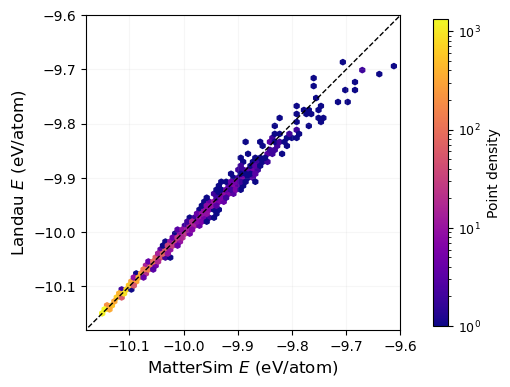

[Energy] R^2=0.995762, MAE=1.168011e-03


In [17]:
#parity plot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error
from matplotlib.ticker import MultipleLocator
import matplotlib as mpl

csv_path = "MLP_test.csv"
df_plot = pd.read_csv(csv_path)

energy_scale = 1.0 / 12.0   # →eV/atom
x_E = df_plot["E_data"].to_numpy() * energy_scale
y_E = df_plot["E_pred"].to_numpy() * energy_scale

gridsize = 100
cmap = "plasma"
tick_fs = 10
label_fs = 12
title_fs = 12
line_kwargs = dict(color="k", linestyle="--", linewidth=1.0)

def auto_limits(x, y, margin_ratio=0.05):
    x = np.asarray(x)
    y = np.asarray(y)
    mask = np.isfinite(x) & np.isfinite(y)
    if not mask.any():
        return -1.0, 1.0
    xy = np.concatenate([x[mask], y[mask]])
    xmin = np.nanmin(xy)
    xmax = np.nanmax(xy)
    span = xmax - xmin
    if span <= 0:
        span = 1.0
    m = span * margin_ratio
    lo = xmin - m
    hi = xmax + m
    return lo, hi

def add_panel(ax, x, y, title, xlabel=None, ylabel=None, show_cbar=False):
    hb = ax.hexbin(x, y, gridsize=gridsize, cmap=cmap, mincnt=1, bins="log")

    lo, hi = auto_limits(x, y)
    ax.plot([lo, hi], [lo, hi], **line_kwargs)

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect("equal", adjustable="box")

    tick_interval = (hi - lo) / 5.0
    ax.xaxis.set_major_locator(MultipleLocator(tick_interval))
    ax.yaxis.set_major_locator(MultipleLocator(tick_interval))
    ax.tick_params(labelsize=tick_fs)
    ax.grid(True, alpha=0.3)

    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() >= 2:
        r2 = r2_score(x[mask], y[mask])
        mae = mean_absolute_error(x[mask], y[mask])
        ax.text(
            0.03,
            0.97,
            "",
            transform=ax.transAxes,
            va="top",
            ha="left",
            fontsize=10,
            bbox=dict(boxstyle="round", fc="white", ec="0.8", alpha=0.9),
        )

    if xlabel:
        ax.set_xlabel(xlabel, fontsize=label_fs)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=label_fs)
    ax.set_title(title, fontsize=title_fs)

    if show_cbar:
        cb = plt.colorbar(hb, ax=ax, shrink=0.85)
        cb.set_label("Point density", fontsize=10)
        cb.ax.tick_params(labelsize=9)

# Energy-only figure
mpl.rcdefaults()
fig, ax = plt.subplots(figsize=(5, 4), constrained_layout=True)

add_panel(
    ax,
    x_E,
    y_E,
    title="",
    xlabel="MatterSim $E$ (eV/atom)" if energy_scale != 1.0 else "Reference $E$ (arb.)",
    ylabel="Landau $E$ (eV/atom)" if energy_scale != 1.0 else "MLP $E$ (arb.)",
    show_cbar=True,
)

ax.set_xlim(-10.18, -9.6)
ax.set_ylim(-10.18, -9.6)

major_step = 0.1
ax.xaxis.set_major_locator(MultipleLocator(major_step))
ax.yaxis.set_major_locator(MultipleLocator(major_step))
ax.grid(True, which="major", alpha=0.1)
plt.savefig("parity_plot.png", dpi=300, bbox_inches="tight")
plt.show()

mE = np.isfinite(x_E) & np.isfinite(y_E)
if mE.sum() >= 2:
    r2E = r2_score(x_E[mE], y_E[mE])
    maeE = mean_absolute_error(x_E[mE], y_E[mE])
    print(f"[Energy] R^2={r2E:.6f}, MAE={maeE:.6e}")

/tmp/ipykernel_2178500/2080245372.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20")


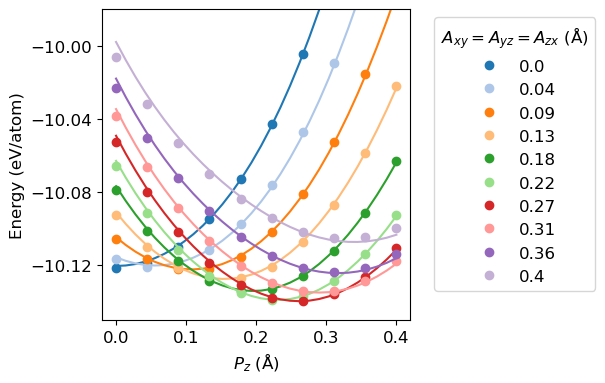

In [15]:
# A and P mode coupling test plot
import matplotlib.ticker as ticker
mpl.rcdefaults()
mpl.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "legend.title_fontsize": 12,
})

plt.figure(figsize=(6.3, 4))

cmap = plt.cm.get_cmap("tab20")

A_list = np.linspace(0, 0.4, 10)
frames_data   = []
frames_fit    = []
for i in range(0,len(A_list)):
  Tx_3=0.3
  A_3=A_list[i]
  data_3 = pd.read_csv("grid_strain11005_TxAxyAyzAzx_Pz_6A_test.csv")
  #data=data[data["Tx"] == Tx]
  data_3=data_3.query("abs(Tx - @Tx_3) < 1e-8")
  data_3=data_3.query("abs(Axy - @A_3) < 1e-8")
  data_3=data_3.query("abs(Ayz - @A_3) < 1e-8")
  data_3=data_3.query("abs(Azx - @A_3) < 1e-8")
  Tx_data_3 = data_3["Tx"].values
  Ty_data_3 = data_3["Ty"].values
  Tz_data_3 = data_3["Tz"].values
  Axy_data_3 = data_3["Axy"].values
  Axz_data_3 = data_3["Axz"].values
  Ayz_data_3 = data_3["Ayz"].values
  Ayx_data_3 = data_3["Ayx"].values
  Azx_data_3 = data_3["Azx"].values
  Azy_data_3 = data_3["Azy"].values
  Px_data_3 = data_3["Px"].values
  Py_data_3 = data_3["Py"].values
  Pz_data_3 = data_3["Pz"].values
  strain11_data_3 = data_3["strain11"].values
  strain22_data_3 = data_3["strain22"].values
  strain33_data_3 = data_3["strain33"].values
  strain12_data_3 = data_3["strain12"].values
  strain23_data_3 = data_3["strain23"].values
  strain31_data_3 = data_3["strain31"].values
  E_data_3  = data_3["Energy"].values

  fit_num=len(E_data_3)
  fit_num=30
  Tx_fit_3 = np.linspace(np.min(Tx_3), np.max(Tx_3), fit_num)
  Ty_fit_3 = np.linspace(0, 0, fit_num)
  Tz_fit_3 = np.linspace(0, 0, fit_num)

  Axy_fit_3 = np.linspace(np.min(A_3), np.max(A_3), fit_num)
  Ayz_fit_3 = np.linspace(np.min(A_3), np.max(A_3), fit_num)
  Azx_fit_3 = np.linspace(np.min(A_3), np.max(A_3), fit_num)
  Axz_fit_3 = np.linspace(0, 0, fit_num)
  Ayx_fit_3 = np.linspace(0, 0, fit_num)
  Azy_fit_3 = np.linspace(0, 0, fit_num)

  Px_fit_3 = np.linspace(0, 0, fit_num)
  Py_fit_3 = np.linspace(0, 0, fit_num)
  Pz_fit_3 = np.linspace(0, 0.4, fit_num)

  strain11_fit_3 = np.linspace(0.05, 0.05, fit_num)
  strain22_fit_3 = np.linspace(0, 0, fit_num)
  strain33_fit_3 = np.linspace(0, 0, fit_num)
  strain12_fit_3 = np.linspace(0, 0, fit_num)
  strain23_fit_3 = np.linspace(0, 0, fit_num)
  strain31_fit_3 = np.linspace(0, 0, fit_num)
  #X_fit_3 = (Tx_fit_3,Ty_fit_3,Tz_fit_3,Ax_fit_3,Ay_fit_3,Az_fit_3,Px_fit_3,Py_fit_3,Pz_fit_3,
  #         strain11_fit_3, strain22_fit_3, strain33_fit_3, strain12_fit_3, strain23_fit_3, strain31_fit_3)
  #X = landau_matrix(X_fit_3)
  #E_fit = X.T @ params_l + np.full_like(Tx_fit_3, ref_energy)
  X_fit_mlp = np.column_stack([
        strain11_fit_3, strain22_fit_3, strain33_fit_3, strain12_fit_3, strain23_fit_3, strain31_fit_3,
        Tx_fit_3, Ty_fit_3, Tz_fit_3,
        Axy_fit_3, Axz_fit_3, Ayz_fit_3, Ayx_fit_3, Azx_fit_3, Azy_fit_3,
        Px_fit_3, Py_fit_3, Pz_fit_3,
    ])
  # Prediction in standardized space
  X_fit_mlp_n = (X_fit_mlp - X_mean) / X_std
  E_std_pred, dEstd_dz_mode = predict_group_averaged_affine(params, X_fit_mlp_n, MSTD, BIAS, alpha_tail=alpha_tail, force_idx=force_idx, batch_size=16384)
  E_pred, F_pred_mode = destandardize_energy_force(E_std_pred, dEstd_dz_mode, y_mean, y_std, X_std, force_idx)

  plt.plot(Pz_data_3, E_data_3/12, 'o',color=cmap(i), label=round(A_3,2))
  plt.plot(Pz_fit_3, E_pred/12, '-',color=cmap(i))

plt.xlabel("$P_z$ (Å)")
plt.ylabel("Energy (eV/atom)")
plt.ylim(-10.15, -9.98)     # Fixed Energy axis range
ax = plt.gca()
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.04))

plt.legend(bbox_to_anchor=(1.05, 1), title='$A_{xy}=A_{yz}=A_{zx}$ (Å)')
plt.tight_layout()
plt.savefig("mode_coupling.png", dpi=300, bbox_inches='tight')
plt.show()


In [16]:
# Time evolution
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)

def step_once(Tx,Ty,Tz, Axy,Axz,Ayz,Ayx,Azx,Azy, Px,Py,Pz,
              s11,s22,s33,s12,s23,s31,
              dt):

    X = jnp.stack([s11, s22, s33, s12, s23, s31,
                   Tx,  Ty,  Tz, Axy, Axz, Ayz, Ayx, Azx, Azy,  Px,  Py,  Pz], axis=-1)  # (...,18)
    X_flat = X.reshape(-1, 18)   # (N,18)
    X_flat_n = (X_flat - X_mean) / X_std

    E_std_pred, dEstd_dz_mode = predict_group_averaged_affine(
        params, X_flat_n, MSTD, BIAS,
        alpha_tail=alpha_tail, force_idx=force_idx, batch_size=1
    )
    E_pred, F_pred_mode = destandardize_energy_force(
        E_std_pred, dEstd_dz_mode, y_mean, y_std, X_std, force_idx
    )

    Tx_new  = Tx  - dt * F_pred_mode[..., 0]
    Ty_new  = Ty  - dt * F_pred_mode[..., 1]
    Tz_new  = Tz  - dt * F_pred_mode[..., 2]
    Axy_new = Axy - dt * F_pred_mode[..., 3]
    Axz_new = Axz - dt * F_pred_mode[..., 4]
    Ayz_new = Ayz - dt * F_pred_mode[..., 5]
    Ayx_new = Ayx - dt * F_pred_mode[..., 6]
    Azx_new = Azx - dt * F_pred_mode[..., 7]
    Azy_new = Azy - dt * F_pred_mode[..., 8]
    Px_new  = Px  - dt * F_pred_mode[..., 9]
    Py_new  = Py  - dt * F_pred_mode[..., 10]
    Pz_new  = Pz  - dt * F_pred_mode[..., 11]

    return Tx_new, Ty_new, Tz_new, Axy_new, Axz_new, Ayz_new, Ayx_new, Azx_new, Azy_new, Px_new, Py_new, Pz_new

step_once_jit = jax.jit(step_once)

Tx = jnp.array([1e-3], dtype=jnp.float64)
Ty = jnp.array([0], dtype=jnp.float64)
Tz = jnp.array([0], dtype=jnp.float64)
Axy = jnp.array([1e-3], dtype=jnp.float64)
Axz = jnp.array([0], dtype=jnp.float64)
Ayz = jnp.array([1e-3], dtype=jnp.float64)
Ayx = jnp.array([0], dtype=jnp.float64)
Azx = jnp.array([1e-3], dtype=jnp.float64)
Azy = jnp.array([0], dtype=jnp.float64)
Px = jnp.array([0], dtype=jnp.float64)
Py = jnp.array([0], dtype=jnp.float64)
Pz = jnp.array([1e-3], dtype=jnp.float64)

s11 = jnp.array([0.05], dtype=jnp.float64)
s22 = jnp.array([0.0 ], dtype=jnp.float64)
s33 = jnp.array([0.0 ], dtype=jnp.float64)
s12 = jnp.array([0.0 ], dtype=jnp.float64)
s23 = jnp.array([0.0 ], dtype=jnp.float64)
s31 = jnp.array([0.0 ], dtype=jnp.float64)

kstep = 500
dt = 1e-2

Tx_hist, Ty_hist, Tz_hist = [], [], []
Axy_hist, Axz_hist, Ayz_hist = [], [], []
Ayx_hist, Azx_hist, Azy_hist = [], [], []
Px_hist, Py_hist, Pz_hist = [], [], []

for kt in range(1, kstep + 1):
    Tx, Ty, Tz, Axy, Axz, Ayz, Ayx, Azx, Azy, Px, Py, Pz = step_once_jit(
        Tx, Ty, Tz, Axy, Axz, Ayz, Ayx, Azx, Azy, Px, Py, Pz,
        s11, s22, s33, s12, s23, s31,
        dt
    )

    # Save the scalar value from shape=(1,)
    Tx_hist.append(float(Tx[0]))
    Ty_hist.append(float(Ty[0]))
    Tz_hist.append(float(Tz[0]))
    Axy_hist.append(float(Axy[0]))
    Axz_hist.append(float(Axz[0]))
    Ayz_hist.append(float(Ayz[0]))
    Ayx_hist.append(float(Ayx[0]))
    Azx_hist.append(float(Azx[0]))
    Azy_hist.append(float(Azy[0]))
    Px_hist.append(float(Px[0]))
    Py_hist.append(float(Py[0]))
    Pz_hist.append(float(Pz[0]))

# Save CSV
import pandas as pd
import numpy as np

t = np.arange(1, kstep + 1)

df_out = pd.DataFrame({
    "step": t,

    "Tx": Tx_hist,
    "Ty": Ty_hist,
    "Tz": Tz_hist,

    "Axy": Axy_hist,
    "Axz": Axz_hist,
    "Ayz": Ayz_hist,

    "Ayx": Ayx_hist,
    "Azx": Azx_hist,
    "Azy": Azy_hist,

    "Px": Px_hist,
    "Py": Py_hist,
    "Pz": Pz_hist,
})

df_out.to_csv("mode_displacements_timestep_d4h.csv", index=False)

print("CSV saved: mode_displacements_timestep_d4h.csv")

CSV saved: mode_displacements_timestep_d4h.csv


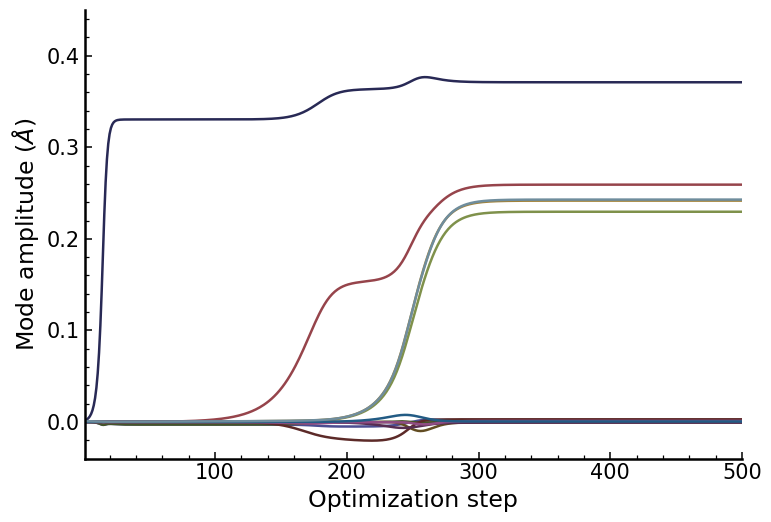

In [18]:
# Plot time evolution
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# =========================
# Data
# =========================
df = pd.read_csv("mode_displacements_timestep_d4h.csv")

mode_names = [
    "Tx", "Ty", "Tz",
    "Axy", "Axz", "Ayz",
    "Ayx", "Azx", "Azy",
    "Px", "Py", "Pz"
]

# =========================
# Color
# =========================
def darken(colors, factor=0.7):
    colors = np.array(colors).copy()
    colors[:, :3] *= factor
    return np.clip(colors, 0, 1)

c1 = mpl.colormaps["tab20b"](np.linspace(0, 1, 20))[::2]
c2 = mpl.colormaps["tab20c"](np.linspace(0, 1, 20))[::2]
colors = np.vstack([c1, c2])[:12]
colors = darken(colors, factor=0.7)

# =========================
# Plot style
# =========================
mpl.rcParams["font.family"] = "DejaVu Sans"
mpl.rcParams["font.size"] = 16
mpl.rcParams["axes.labelsize"] = 17
mpl.rcParams["axes.linewidth"] = 1.2
mpl.rcParams["xtick.labelsize"] = 15
mpl.rcParams["ytick.labelsize"] = 15
mpl.rcParams["legend.fontsize"] = 11
mpl.rcParams["xtick.direction"] = "in"
mpl.rcParams["ytick.direction"] = "in"
mpl.rcParams["xtick.major.size"] = 8
mpl.rcParams["ytick.major.size"] = 8
mpl.rcParams["xtick.minor.size"] = 3
mpl.rcParams["ytick.minor.size"] = 3

# =========================
# plot
# =========================
fig, ax = plt.subplots(figsize=(8.0, 5.5))

for i, mode in enumerate(mode_names):
    ax.plot(
        df["step"],
        df[mode],
        label=mode,
        linewidth=1.8,
        color=colors[i]
    )

# Axis range
ax.set_xlim(df["step"].min(), df["step"].max())
ax.set_ylim(-0.04, 0.45)

# Labels
ax.set_xlabel("Optimization step")
ax.set_ylabel(r"Mode amplitude ($\AA$)")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.8)
ax.spines["bottom"].set_linewidth(1.8)

# Ticks
ax.minorticks_on()
ax.tick_params(which="both", direction="in")
ax.tick_params(which="major", length=5, width=1.1)
ax.tick_params(which="minor", length=3, width=0.9)

fig.tight_layout()
fig.savefig("mode_displacements_timestep_d4h.png", dpi=600, bbox_inches="tight")
plt.show()


## 3. Phase-field simulations

In [1]:
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from functools import partial

import jax
import jax.numpy as jnp

jax.config.update("jax_enable_x64", True)

def _to_device(x):
    return jax.tree_util.tree_map(jax.device_put, x)

def _to_numpy(tree):
    return jax.tree_util.tree_map(lambda x: np.asarray(x), tree)

def load_bulk_params(path, to_device=True):
    with open(path, "rb") as f:
        obj = pickle.load(f)
    return _to_device(obj) if to_device else obj


In [2]:
# Load data
df7 = pd.read_csv("important5000_strain006_cubic_mode01_force_optmax15_stress_QTf_Fmax005_fmodemax005_mattersimM5.csv")
df8 = pd.read_csv("important5000_strain006_ortho_mode01_force_optmax15_stress_QTf_Fmax005_fmodemax005_mattersimM5.csv")

n1 = len(df7)
n2 = len(df8)
chunk_size = 5000
dfs = [df7.iloc[i:i + chunk_size].reset_index(drop=True) for i in range(0, n1, chunk_size)]
dft = [df8.iloc[i:i + chunk_size].reset_index(drop=True) for i in range(0, n2, chunk_size)]

df = pd.concat([dfs[1], dfs[2], dfs[3], dfs[4], dft[1], dft[2], dft[3], dft[4]], axis=0)

force_cols = ["Tx_f","Ty_f","Tz_f","Axy_f","Axz_f","Ayz_f","Ayx_f","Azx_f","Azy_f","Px_f","Py_f","Pz_f"]
X_cols = ["strain11","strain22","strain33","strain12","strain23","strain31",
          "Tx","Ty","Tz","Axy","Axz","Ayz","Ayx","Azx","Azy","Px","Py","Pz"]
mode_cols  = ["Tx","Ty","Tz","Axy","Axz","Ayz","Ayx","Azx","Azy","Px","Py","Pz"]

y = jnp.asarray(df["Energy"].to_numpy(dtype=np.float64))
F = jnp.asarray(df[force_cols].to_numpy(dtype=np.float64))
X = jnp.asarray(df[X_cols].to_numpy(dtype=np.float64))

X_mean = X.mean(0)
X_std  = X.std(0) + 1e-12
y_mean = y.mean()
y_std  = y.std() + 1e-12

Xn = (X - X_mean) / X_std
yn = (y - y_mean) / y_std
Fn = F / y_std * X_std[6:]

bulk_params = load_bulk_params("final_params_invari_df7_20000_df8_20000_Ir1e-3.pkl", to_device=True)

col_index = {c: i for i, c in enumerate(X_cols)}
force_idx = jnp.asarray([col_index[c] for c in mode_cols], dtype=jnp.int32)
print(len(df))


40000


In [9]:
# Symmetry operations
rotation_rule_x90 = {
    "Tx":  ("Tx",  -1),
    "Ty":  ("Tz",  -1),
    "Tz":  ("Ty",  -1),
    "Axy": ("Axz", -1),
    "Axz": ("Axy", +1),
    "Ayz": ("Azy", -1),
    "Ayx": ("Azx", +1),
    "Azx": ("Ayx", +1),
    "Azy": ("Ayz", +1),
    "Px":  ("Px",  +1),
    "Py":  ("Pz",  +1),
    "Pz":  ("Py",  -1),
}

rotation_rule_y180 = {
    "Tx":  ("Tx",  +1),
    "Ty":  ("Ty",  +1),
    "Tz":  ("Tz",  +1),
    "Axy": ("Axy", +1),
    "Axz": ("Axz", -1),
    "Ayz": ("Ayz", -1),
    "Ayx": ("Ayx", -1),
    "Azx": ("Azx", -1),
    "Azy": ("Azy", +1),
    "Px":  ("Px",  -1),
    "Py":  ("Py",  +1),
    "Pz":  ("Pz",  -1),
}

mirror_yz = {
    "Tx":  ("Tx",  -1),
    "Ty":  ("Ty",  -1),
    "Tz":  ("Tz",  -1),
    "Axy": ("Axy", -1),
    "Axz": ("Axz", -1),
    "Ayz": ("Ayz", -1),
    "Ayx": ("Ayx", +1),
    "Azx": ("Azx", +1),
    "Azy": ("Azy", -1),
    "Px":  ("Px",  -1),
    "Py":  ("Py",  +1),
    "Pz":  ("Pz",  +1),
}

def identity_rule(keys):
    return {k: (k, +1) for k in keys}

def compose_rules(r1, r2):
    out = {}
    for k in r2.keys():
        k2, s2 = r2[k]
        k1, s1 = r1[k2]
        out[k] = (k1, s1 * s2)
    return out

def normalize_rule(rule, ordered_keys):
    return tuple((rule[k][0], rule[k][1]) for k in ordered_keys)

def make_matrix_from_rule(rule, X_cols, acted_cols):
    D = len(X_cols)
    M = np.eye(D, dtype=np.float64)
    for c in acted_cols:
        i = X_cols.index(c)
        M[i, :] = 0.0
    for target_c in acted_cols:
        i = X_cols.index(target_c)
        if target_c in rule:
            src_c, sgn = rule[target_c]
            j = X_cols.index(src_c)
            M[i, j] = float(sgn)
        else:
            j = X_cols.index(target_c)
            M[i, j] = 1.0
    return jnp.asarray(M)

def generate_D4h_rules(acted_cols):
    E = identity_rule(acted_cols)
    generators = [
        ("C4x",   rotation_rule_x90),
        ("C2y",   rotation_rule_y180),
        ("sig_h", mirror_yz),
    ]

    ordered_keys = sorted(list(E.keys()))
    seen = {normalize_rule(E, ordered_keys): ("E", E)}
    frontier = [("E", E)]

    while frontier and len(seen) < 16:
        name, rule = frontier.pop(0)
        for gname, g in generators:
            new_rule = compose_rules(rule, g)
            key = normalize_rule(new_rule, ordered_keys)
            if key not in seen:
                new_name = f"{name}*{gname}" if name != "E" else gname
                seen[key] = (new_name, new_rule)
                frontier.append((new_name, new_rule))
            if len(seen) == 16:
                break

    ops = list(seen.values())
    ops.sort(key=lambda x: (len(x[0]), x[0]))
    return ops

def build_group_mats(X_cols, mode_cols):
    ops = generate_D4h_rules(mode_cols)
    mats = []
    names = []
    for op_name, rule in ops:
        M = make_matrix_from_rule(rule, X_cols, acted_cols=mode_cols)
        mats.append(M)
        names.append(op_name)
    GROUP_MATS = jnp.stack(mats, axis=0)
    return GROUP_MATS, names

GROUP_MATS, GROUP_NAMES = build_group_mats(X_cols, mode_cols)

def build_affine_on_standardized_space(GROUP_MATS, X_mean, X_std):
    S   = 1.0 / jnp.asarray(X_std)
    Sm1 = jnp.asarray(X_std)
    mu  = jnp.asarray(X_mean)

    def to_std_affine(M):
        A = (S[:, None]) * M * (Sm1[None, :])
        b = S * (M @ mu - mu)
        return A, b

    A_list, b_list = jax.vmap(to_std_affine, in_axes=0)(GROUP_MATS)
    return A_list, b_list

MSTD, BIAS = build_affine_on_standardized_space(GROUP_MATS, X_mean, X_std)

# =========================================================
# MLP
# =========================================================
def mlp_forward(bulk_params, x):
    h = x
    for (W, b) in bulk_params[:-1]:
        h = h @ W + b
        h = h * jax.nn.sigmoid(h)
    W, b = bulk_params[-1]
    return (h @ W + b)[0]

@jax.jit
def energy_std(bulk_params, z_std, alpha_tail):
    E = mlp_forward(bulk_params, z_std)
    E = E + alpha_tail * jnp.sum(z_std * z_std) ** 2
    return E

# =========================================================
# Inference
# =========================================================
@partial(jax.jit, static_argnames=("batch_size",))
def predict_group_averaged_affine_jit(
    bulk_params, Xn, MSTD, BIAS, *, alpha_tail=0.0, force_idx=None, batch_size=8192
):
    N, D = Xn.shape
    pad = (batch_size - (N % batch_size)) % batch_size
    Xp = jnp.pad(Xn, ((0, pad), (0, 0)))
    n_batch = Xp.shape[0] // batch_size
    Xbatches = Xp.reshape(n_batch, batch_size, D)

    if force_idx is None:
        force_idx_local = jnp.arange(D, dtype=jnp.int32)
    else:
        force_idx_local = force_idx

    def per_batch(_, Zb):
        def per_op(A, b):
            Ub = Zb @ A.T + b
            E_b = jax.vmap(lambda z: energy_std(bulk_params, z, alpha_tail))(Ub)
            grad_u = jax.vmap(
                lambda z: jax.grad(energy_std, argnums=1)(bulk_params, z, alpha_tail)
            )(Ub)
            grad_z = grad_u @ A
            return E_b, grad_z

        Em_g, Fm_g = jax.vmap(per_op, in_axes=(0, 0))(MSTD, BIAS)
        E_avg = jnp.mean(Em_g, axis=0)
        F_avg = jnp.mean(Fm_g, axis=0)
        F_avg = F_avg[:, force_idx_local]
        return None, (E_avg, F_avg)

    _, (E_batches, F_batches) = jax.lax.scan(per_batch, None, Xbatches)

    E_std = E_batches.reshape(-1)[:N]
    F_std = F_batches.reshape(-1, force_idx_local.shape[0])[:N]
    return E_std, F_std

@jax.jit
def destandardize_energy_force(E_std, F_std, y_mean, y_std, X_std, force_idx=None):
    E = y_std * E_std + y_mean
    if force_idx is None:
        Xstd_slice = jnp.asarray(X_std)
    else:
        Xstd_slice = jnp.asarray(X_std)[force_idx]
    F = (y_std * F_std) / Xstd_slice
    return E, F

# =========================================================
# PFM functions
# =========================================================
@jax.jit
def apply_mask_to_k_update(update_k, mask):
    update_real = jnp.fft.ifftn(update_k).real
    return jnp.fft.fftn(mask * update_real)

@partial(jax.jit, static_argnames=("batch_size",))
def Landau_energy(
    Tx,Ty,Tz, Axy,Axz,Ayz,Ayx,Azx,Azy, Px,Py,Pz, s11,s22,s33,s12,s23,s31,
    *, batch_size=8192
):
    X = jnp.stack(
        [s11, s22, s33, s12, s23, s31,
         Tx,  Ty,  Tz,  Axy, Axz, Ayz, Ayx, Azx, Azy,  Px,  Py,  Pz],
        axis=-1
    )

    Nx, Ny, Nz = Tx.shape
    X_flat_n = (X.reshape((Nx * Ny * Nz, 18)) - X_mean) / X_std

    E_std_pred, dEstd_dz_mode = predict_group_averaged_affine_jit(
        bulk_params, X_flat_n, MSTD, BIAS,
        alpha_tail=0.0, force_idx=force_idx, batch_size=batch_size
    )
    E_pred, F_pred_mode = destandardize_energy_force(
        E_std_pred, dEstd_dz_mode, y_mean, y_std, X_std, force_idx
    )

    F_mode = jnp.reshape(F_pred_mode, (Nx, Ny, Nz, -1))
    Gk = jnp.fft.fftn(F_mode, axes=(0, 1, 2))
    Gk = jnp.moveaxis(Gk, -1, 0)
    return Gk

@partial(jax.jit, static_argnames=("maxstep",))
def electric_jit(Px, Py, Pz, epsr, tol, maxstep, KX, KY, KZ, K2, eps0):
    Px_C = (-1.8) * Px
    Py_C = (-1.8) * Py
    Pz_C = (-1.8) * Pz

    Pxk_C = jnp.fft.fftn(Px_C)
    Pyk_C = jnp.fft.fftn(Py_C)
    Pzk_C = jnp.fft.fftn(Pz_C)

    epsr_hom = jnp.max(epsr)
    el_gr = 1.0 / (epsr_hom * K2)

    init_elx = jnp.zeros_like(Px)
    init_ely = jnp.zeros_like(Py)
    init_elz = jnp.zeros_like(Pz)
    init_phi = jnp.zeros_like(Px)

    def cond_fn(state):
        t, elx, ely, elz, phi, delta = state
        return jnp.logical_and(t < maxstep, delta > tol)

    def body_fn(state):
        t, elx, ely, elz, phi, delta = state

        eps_ex = (epsr - epsr_hom) * elx
        eps_ey = (epsr - epsr_hom) * ely
        eps_ez = (epsr - epsr_hom) * elz

        eps_exk = jnp.fft.fftn(eps_ex)
        eps_eyk = jnp.fft.fftn(eps_ey)
        eps_ezk = jnp.fft.fftn(eps_ez)

        termx = (eps_exk + Pxk_C / eps0) * KX
        termy = (eps_eyk + Pyk_C / eps0) * KY
        termz = (eps_ezk + Pzk_C / eps0) * KZ

        phi_k = -1j * el_gr * (termx + termy + termz)

        elxk = -1j * KX * phi_k
        elyk = -1j * KY * phi_k
        elzk = -1j * KZ * phi_k

        phi_new = jnp.fft.ifftn(phi_k).real
        elx_new = jnp.fft.ifftn(elxk).real
        ely_new = jnp.fft.ifftn(elyk).real
        elz_new = jnp.fft.ifftn(elzk).real

        delta_new = jnp.sqrt(
            jnp.max((elx - elx_new) ** 2 + (ely - ely_new) ** 2 + (elz - elz_new) ** 2)
        )

        return (t + 1, elx_new, ely_new, elz_new, phi_new, delta_new)

    init_state = (0, init_elx, init_ely, init_elz, init_phi, jnp.inf)
    _, elx, ely, elz, phi, delta = jax.lax.while_loop(cond_fn, body_fn, init_state)

    elx_n = elx / 1.2186e9 * (-1.8)
    ely_n = ely / 1.2186e9 * (-1.8)
    elz_n = elz / 1.2186e9 * (-1.8)
    return elx_n, ely_n, elz_n, elx, ely, elz, phi

def triangle_E_schedule(Emax, nE_half):
    seg1 = np.linspace(0.0,   Emax,  nE_half,     endpoint=False)
    seg2 = np.linspace(Emax, -Emax,  2*nE_half,   endpoint=False)
    seg3 = np.linspace(-Emax, Emax,  2*nE_half,   endpoint=False)
    seg4 = np.linspace(Emax,  0.0,   nE_half + 1, endpoint=True)
    return np.concatenate([seg1, seg2, seg3, seg4])

@partial(jax.jit, static_argnames=("batch_size", "maxstep_elec"))
def pfm_step(modes, modes_k, strains, chi, epsr, Ez_scalar, dt,
             KX, KY, KZ, K2, eps0, tol_elec, maxstep_elec, *, batch_size=8192):
    Tx,Ty,Tz,Axy,Axz,Ayz,Ayx,Azx,Azy,Px,Py,Pz = modes
    s11,s22,s33,s12,s23,s31 = strains

    G_k = Landau_energy(
        Tx, Ty, Tz, Axy, Axz, Ayz, Ayx, Azx, Azy, Px, Py, Pz,
        s11, s22, s33, s12, s23, s31,
        batch_size=batch_size
    )

    elx_n, ely_n, elz_n, elx, ely, elz, phi = electric_jit(
        Px, Py, Pz, epsr, tol_elec, maxstep_elec, KX, KY, KZ, K2, eps0
    )

    elx_nk = jnp.fft.fftn(elx_n)
    ely_nk = jnp.fft.fftn(ely_n)
    elz_n_total = (elz + Ez_scalar) / 1.2186e9 * (-1.8)
    elz_nk = jnp.fft.fftn(elz_n_total)

    dG_k = G_k
    dG_k = dG_k.at[9].add(-elx_nk)
    dG_k = dG_k.at[10].add(-ely_nk)
    dG_k = dG_k.at[11].add(-elz_nk)

    dG_k = jax.vmap(apply_mask_to_k_update, in_axes=(0, None))(dG_k, chi)

    modes_k_new = modes_k - dt * dG_k
    modes_new = jnp.fft.ifftn(modes_k_new, axes=(1, 2, 3)).real
    dmax = jnp.max(jnp.abs(modes_new - modes))
    return modes_new, modes_k_new, dmax

@partial(jax.jit, static_argnames=("max_steps", "batch_size", "maxstep_elec"))
def relax_until_converged(
    modes0, modes_k0, strains, chi, epsr, Ez_scalar, dt, mode_diff_max,
    KX, KY, KZ, K2, eps0, tol_elec,
    *, max_steps, batch_size=8192, maxstep_elec=1000
):
    def cond_fn(state):
        i, modes, modes_k, dmax = state
        return jnp.logical_and(i < max_steps, dmax > mode_diff_max)

    def body_fn(state):
        i, modes, modes_k, dmax = state
        modes_new, modes_k_new, dmax_new = pfm_step(
            modes, modes_k, strains, chi, epsr, Ez_scalar, dt,
            KX, KY, KZ, K2, eps0, tol_elec, maxstep_elec,
            batch_size=batch_size
        )
        return (i + 1, modes_new, modes_k_new, dmax_new)

    init_state = (jnp.array(0), modes0, modes_k0, jnp.array(jnp.inf))
    return jax.lax.while_loop(cond_fn, body_fn, init_state)

# Strain utilities
@partial(jax.jit, static_argnames=("batch_size", "maxstep_elec"))
def pfm_step_fixed(modes, modes_k, strains, chi, epsr, Ez_scalar, dt,
                   KX, KY, KZ, K2, eps0, tol_elec, maxstep_elec, *, batch_size=8192):
    Tx,Ty,Tz,Axy,Axz,Ayz,Ayx,Azx,Azy,Px,Py,Pz = modes
    s11,s22,s33,s12,s23,s31 = strains

    G_k = Landau_energy(
        Tx, Ty, Tz, Axy, Axz, Ayz, Ayx, Azx, Azy, Px, Py, Pz,
        s11, s22, s33, s12, s23, s31,
        batch_size=batch_size
    )

    elx_n, ely_n, elz_n, elx, ely, elz, phi = electric_jit(
        Px, Py, Pz, epsr, tol_elec, maxstep_elec, KX, KY, KZ, K2, eps0
    )

    elx_nk = jnp.fft.fftn(elx_n)
    ely_nk = jnp.fft.fftn(ely_n)
    elz_n_total = (elz + Ez_scalar) / 1.2186e9 * (-1.8)
    elz_nk = jnp.fft.fftn(elz_n_total)

    dG_k = G_k
    dG_k = dG_k.at[9].add(-elx_nk)
    dG_k = dG_k.at[10].add(-ely_nk)
    dG_k = dG_k.at[11].add(-elz_nk)

    dG_k = jax.vmap(apply_mask_to_k_update, in_axes=(0, None))(dG_k, chi)

    modes_k_new = modes_k - dt * (update_mask * dG_k)
    modes_new = jnp.fft.ifftn(modes_k_new, axes=(1, 2, 3)).real
    dmax = jnp.max(jnp.abs(modes_new - modes))
    return modes_new, modes_k_new, dmax

@jax.jit
def make_strains(strain):
    s11 = jnp.full((Nx, Ny, Nz), strain, dtype=jnp.float64)
    z0  = jnp.zeros((Nx, Ny, Nz), dtype=jnp.float64)
    return jnp.stack([s11, z0, z0, z0, z0, z0], axis=0)

@jax.jit
def init_modes(chi):
    Tx  = 1e-3 * chi
    Ty  = 0.0  * chi
    Tz  = 0.0  * chi
    Axy = 1e-3 * chi
    Axz = 0.0  * chi
    Ayz = 1e-3 * chi
    Ayx = 0.0  * chi
    Azx = 1e-3 * chi
    Azy = 0.0  * chi
    Px  = 0.0  * chi
    Py  = 0.0  * chi
    Pz  = 1e-3 * chi

    return jnp.stack([Tx, Ty, Tz, Axy, Axz, Ayz, Ayx, Azx, Azy, Px, Py, Pz], axis=0)

@partial(jax.jit, static_argnames=("batch_size",))
def run_one_strain(strain, chi, batch_size=8192):
    modes = init_modes(chi)
    modes_k = jnp.fft.fftn(modes, axes=(1, 2, 3))
    strains = make_strains(strain)

    Ez_scalar = jnp.asarray(0.0, dtype=jnp.float64)

    def cond_fn(state):
        kt, last_kt, modes, modes_k, dmax = state
        return jnp.logical_and(
            kt < kstep,
            jnp.logical_or(
                kt < min_step,
                dmax >= mode_diff_max
            )
        )

    def body_fn(state):
        kt, last_kt, modes, modes_k, dmax = state
        modes_new, modes_k_new, dmax_new = pfm_step_fixed(
            modes,
            modes_k,
            strains,
            chi,
            epsr,
            Ez_scalar,
            dt,
            KX, KY, KZ, K2,
            eps0,
            tol_elec,
            maxstep_elec,
            batch_size=batch_size
        )
        return (kt + 1, kt, modes_new, modes_k_new, dmax_new)
    
    init_state = (
        jnp.array(0, dtype=jnp.int32),
        jnp.array(kstep - 1, dtype=jnp.int32),
        modes,
        modes_k,
        jnp.array(jnp.inf, dtype=jnp.float64),
    )

    kt, last_kt, modes, modes_k, dmax = jax.lax.while_loop(
        cond_fn, body_fn, init_state
    )

    converged = jnp.logical_and(
        kt >= min_step,
        dmax <= mode_diff_max
    )

    center = modes[:, ix0, iy0, iz0]
    
    return {
        "strain": strain,
        "converged": converged,
        "kt_final": last_kt,
        "dmax_final": dmax,
        "center": center,
    }


Initial relaxation finished 221 9.944678860243639e-06
0.0
7500000.0
15000000.0
22500000.0
30000000.0
37500000.0
45000000.0
52500000.0
60000000.0
67500000.0
75000000.0
82500000.0
90000000.0
97500000.0
105000000.0
112500000.0
120000000.0
127500000.0
135000000.0
142500000.0
150000000.0
157500000.0
165000000.0
172500000.0
180000000.0
187500000.0
195000000.0
202500000.0
210000000.0
217500000.0
225000000.0
232500000.0
240000000.0
247500000.0
255000000.0
262500000.0
270000000.0
277500000.0
285000000.0
292500000.0
300000000.0
307500000.0
315000000.0
322500000.0
330000000.0
337500000.0
345000000.0
352500000.0
360000000.0
367500000.0
375000000.0
382500000.0
390000000.0
397500000.0
405000000.0
412500000.0
420000000.0
427500000.0
435000000.0
442500000.0
450000000.0
457500000.0
465000000.0
472500000.0
480000000.0
487500000.0
495000000.0
502500000.0
510000000.0
517500000.0
525000000.0
532500000.0
540000000.0
547500000.0
555000000.0
562500000.0
570000000.0
577500000.0
585000000.0
592500000.0
60000000

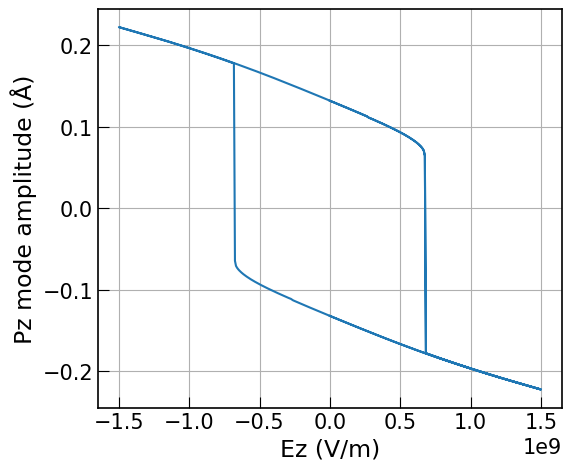

In [21]:
# Hysteresis calculation (film)
Nx = 32
Ny = 32
Nz = 32
dx = dy = dz = 1e-9

Lx, Ly, Lz = Nx * dx, Ny * dy, Nz * dz
x = jnp.linspace(-Lx / 2, Lx / 2, Nx, endpoint=False)
y = jnp.linspace(-Ly / 2, Ly / 2, Ny, endpoint=False)
z = jnp.linspace(-Lz / 2, Lz / 2, Nz, endpoint=False)

ix0, iy0, iz0 = Nx // 2, Ny // 2, Nz // 2

t_film = 8 * dx
w_int  = 0.25 * dx
chi_1d = 0.5 * (1.0 - jnp.tanh((jnp.abs(z) - t_film / 2) / w_int))
chi = jnp.ones((Nx, Ny, 1), dtype=jnp.float64) * chi_1d[None, None, :]

eps0 = 8.854e-12
eps_film = 25.0
epsr = 1.0 + (eps_film - 1.0) * chi

kx = jnp.fft.fftfreq(Nx, d=dx) * 2.0 * jnp.pi
ky = jnp.fft.fftfreq(Ny, d=dy) * 2.0 * jnp.pi
kz = jnp.fft.fftfreq(Nz, d=dz) * 2.0 * jnp.pi
KX, KY, KZ = jnp.meshgrid(kx, ky, kz, indexing="ij")
K2 = KX**2 + KY**2 + KZ**2
K2 = K2.at[0, 0, 0].set(1e-20)

dt = 1e-2
kstep_relax   = 500
n_relax_per_E = 500
Emax          = 1.5e9
nE_half       = 200
Ez_schedule   = triangle_E_schedule(Emax, nE_half)
mode_diff_max = 1e-5
tol_elec      = 1e5
maxstep_elec  = 1000
batch_size    = 8192

Tx  = 0.25 * chi
Ty  = 0.0 * chi
Tz  = 0.0 * chi
Axy = 0.25 * chi
Axz = 0.0 * chi
Ayz = 0.25 * chi
Ayx = 0.0 * chi
Azx = 0.25 * chi
Azy = 0.0 * chi
Px  = 0.0 * chi
Py  = 0.0 * chi
Pz  = 0.25 * chi

s11 = jnp.full((Nx, Ny, Nz), 0.05, dtype=jnp.float64)
s22 = jnp.zeros((Nx, Ny, Nz), dtype=jnp.float64)
s33 = jnp.zeros((Nx, Ny, Nz), dtype=jnp.float64)
s12 = jnp.zeros((Nx, Ny, Nz), dtype=jnp.float64)
s23 = jnp.zeros((Nx, Ny, Nz), dtype=jnp.float64)
s31 = jnp.zeros((Nx, Ny, Nz), dtype=jnp.float64)

modes = jnp.stack([Tx,Ty,Tz,Axy,Axz,Ayz,Ayx,Azx,Azy,Px,Py,Pz], axis=0)
modes_k = jnp.fft.fftn(modes, axes=(1, 2, 3))
strains = jnp.stack([s11,s22,s33,s12,s23,s31], axis=0)

# Initial relaxation
kt_final, modes, modes_k, dmax_final = relax_until_converged(
    modes, modes_k, strains, chi, epsr, 0.0, dt, mode_diff_max,
    KX, KY, KZ, K2, eps0, tol_elec,
    max_steps=kstep_relax, batch_size=batch_size, maxstep_elec=maxstep_elec
)

print("Initial relaxation finished", int(kt_final), float(dmax_final))

# Electric-field sweep
Ez_hist = []
Pz_hist = []
P_hist  = []

for Elecz in Ez_schedule:
    _, modes, modes_k, dmax_final = relax_until_converged(
        modes, modes_k, strains, chi, epsr, float(Elecz), dt, mode_diff_max,
        KX, KY, KZ, K2, eps0, tol_elec,
        max_steps=n_relax_per_E, batch_size=batch_size, maxstep_elec=maxstep_elec
    )

    Pz_val = float(modes[11, ix0, iy0, iz0])
    Ez_hist.append(float(Elecz))
    Pz_hist.append(Pz_val)
    P_hist.append(-1.8 * Pz_val)
    print(Elecz)

Ez_hist = np.asarray(Ez_hist)
Pz_hist = np.asarray(Pz_hist)
P_hist  = np.asarray(P_hist)

plt.figure(figsize=(6, 5))
plt.plot(Ez_hist, Pz_hist, linewidth=1.5)
plt.xlabel("Ez (V/m)")
plt.ylabel("Pz mode amplitude (Å)")
plt.grid(True)
plt.tight_layout()
plt.show()

df_out = pd.DataFrame({
    "step": np.arange(len(Ez_hist), dtype=int),
    "Ez_V_per_m": Ez_hist,
    "Pz_mode_A": Pz_hist,
    "P_C_per_m2": P_hist,
})
df_out.to_csv("hysteresis_P_E_film_PFM.csv", index=False)


Initial relaxation finished 52 9.828387144777961e-06
0.0
7500000.0
15000000.0
22500000.0
30000000.0
37500000.0
45000000.0
52500000.0
60000000.0
67500000.0
75000000.0
82500000.0
90000000.0
97500000.0
105000000.0
112500000.0
120000000.0
127500000.0
135000000.0
142500000.0
150000000.0
157500000.0
165000000.0
172500000.0
180000000.0
187500000.0
195000000.0
202500000.0
210000000.0
217500000.0
225000000.0
232500000.0
240000000.0
247500000.0
255000000.0
262500000.0
270000000.0
277500000.0
285000000.0
292500000.0
300000000.0
307500000.0
315000000.0
322500000.0
330000000.0
337500000.0
345000000.0
352500000.0
360000000.0
367500000.0
375000000.0
382500000.0
390000000.0
397500000.0
405000000.0
412500000.0
420000000.0
427500000.0
435000000.0
442500000.0
450000000.0
457500000.0
465000000.0
472500000.0
480000000.0
487500000.0
495000000.0
502500000.0
510000000.0
517500000.0
525000000.0
532500000.0
540000000.0
547500000.0
555000000.0
562500000.0
570000000.0
577500000.0
585000000.0
592500000.0
600000000

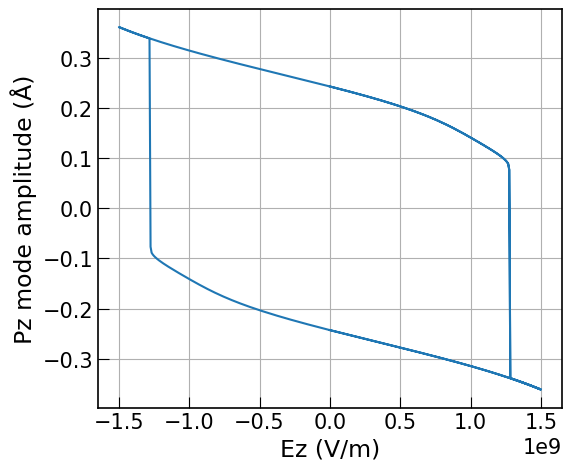

In [22]:
# Hysteresis calculation (bulk)
Nx = 32
Ny = 32
Nz = 32
dx = dy = dz = 1e-9

Lx, Ly, Lz = Nx * dx, Ny * dy, Nz * dz
x = jnp.linspace(-Lx / 2, Lx / 2, Nx, endpoint=False)
y = jnp.linspace(-Ly / 2, Ly / 2, Ny, endpoint=False)
z = jnp.linspace(-Lz / 2, Lz / 2, Nz, endpoint=False)

ix0, iy0, iz0 = Nx // 2, Ny // 2, Nz // 2

ones = jnp.ones((Nx, Ny, Nz))

eps0 = 8.854e-12
epsr = 25.0 * ones

kx = jnp.fft.fftfreq(Nx, d=dx) * 2.0 * jnp.pi
ky = jnp.fft.fftfreq(Ny, d=dy) * 2.0 * jnp.pi
kz = jnp.fft.fftfreq(Nz, d=dz) * 2.0 * jnp.pi
KX, KY, KZ = jnp.meshgrid(kx, ky, kz, indexing="ij")
K2 = KX**2 + KY**2 + KZ**2
K2 = K2.at[0, 0, 0].set(1e-20)

dt = 1e-2
kstep_relax   = 500
n_relax_per_E = 500
Emax          = 1.5e9
nE_half       = 200
Ez_schedule   = triangle_E_schedule(Emax, nE_half)
mode_diff_max = 1e-5
tol_elec      = 1e5
maxstep_elec  = 1000
batch_size    = 8192

Tx  = 0.25 * ones
Ty  = 0.0 * ones
Tz  = 0.0 * ones
Axy = 0.25 * ones
Axz = 0.0 * ones
Ayz = 0.25 * ones
Ayx = 0.0 * ones
Azx = 0.25 * ones
Azy = 0.0 * ones
Px  = 0.0 * ones
Py  = 0.0 * ones
Pz  = 0.25 * ones

s11 = jnp.full((Nx, Ny, Nz), 0.05, dtype=jnp.float64)
s22 = jnp.zeros((Nx, Ny, Nz), dtype=jnp.float64)
s33 = jnp.zeros((Nx, Ny, Nz), dtype=jnp.float64)
s12 = jnp.zeros((Nx, Ny, Nz), dtype=jnp.float64)
s23 = jnp.zeros((Nx, Ny, Nz), dtype=jnp.float64)
s31 = jnp.zeros((Nx, Ny, Nz), dtype=jnp.float64)

modes = jnp.stack([Tx,Ty,Tz,Axy,Axz,Ayz,Ayx,Azx,Azy,Px,Py,Pz], axis=0)
modes_k = jnp.fft.fftn(modes, axes=(1, 2, 3))
strains = jnp.stack([s11,s22,s33,s12,s23,s31], axis=0)

# Initial relaxation
kt_final, modes, modes_k, dmax_final = relax_until_converged(
    modes, modes_k, strains, ones, epsr, 0.0, dt, mode_diff_max,
    KX, KY, KZ, K2, eps0, tol_elec,
    max_steps=kstep_relax, batch_size=batch_size, maxstep_elec=maxstep_elec
)

print("Initial relaxation finished", int(kt_final), float(dmax_final))

# Electric-field sweep
Ez_hist = []
Pz_hist = []
P_hist  = []

for Elecz in Ez_schedule:
    _, modes, modes_k, dmax_final = relax_until_converged(
        modes, modes_k, strains, ones, epsr, float(Elecz), dt, mode_diff_max,
        KX, KY, KZ, K2, eps0, tol_elec,
        max_steps=n_relax_per_E, batch_size=batch_size, maxstep_elec=maxstep_elec
    )

    Pz_val = float(modes[11, ix0, iy0, iz0])
    Ez_hist.append(float(Elecz))
    Pz_hist.append(Pz_val)
    P_hist.append(-1.8 * Pz_val)
    print(Elecz)

Ez_hist = np.asarray(Ez_hist)
Pz_hist = np.asarray(Pz_hist)
P_hist  = np.asarray(P_hist)

plt.figure(figsize=(6, 5))
plt.plot(Ez_hist, Pz_hist, linewidth=1.5)
plt.xlabel("Ez (V/m)")
plt.ylabel("Pz mode amplitude (Å)")
plt.grid(True)
plt.tight_layout()
plt.show()

df_out = pd.DataFrame({
    "step": np.arange(len(Ez_hist), dtype=int),
    "Ez_V_per_m": Ez_hist,
    "Pz_mode_A": Pz_hist,
    "P_C_per_m2": P_hist,
})
df_out.to_csv("hysteresis_P_E_bulk_PFM.csv", index=False)


In [11]:
# Strain dependence (film)
Nx = 32
Ny = 32
Nz = 32
dx = dy = dz = 1e-9

Lx, Ly, Lz = Nx * dx, Ny * dy, Nz * dz
x = jnp.linspace(-Lx / 2, Lx / 2, Nx, endpoint=False)
y = jnp.linspace(-Ly / 2, Ly / 2, Ny, endpoint=False)
z = jnp.linspace(-Lz / 2, Lz / 2, Nz, endpoint=False)

ix0, iy0, iz0 = Nx // 2, Ny // 2, Nz // 2

t_film = 8 * dx
w_int  = 0.25e-9
chi_1d = 0.5 * (1.0 - jnp.tanh((jnp.abs(z) - t_film / 2) / w_int))
chi = jnp.ones((Nx, Ny, 1), dtype=jnp.float64) * chi_1d[None, None, :]

# Dielectric settings
eps0 = 8.854e-12
eps_film = 25.0
epsr = 1.0 + (eps_film - 1.0) * chi

# FFT k-grid
kx = jnp.fft.fftfreq(Nx, d=dx) * (2.0 * jnp.pi)
ky = jnp.fft.fftfreq(Ny, d=dy) * (2.0 * jnp.pi)
kz = jnp.fft.fftfreq(Nz, d=dz) * (2.0 * jnp.pi)
KX, KY, KZ = jnp.meshgrid(kx, ky, kz, indexing="ij")
K2 = KX**2 + KY**2 + KZ**2
K2 = K2.at[0, 0, 0].set(1e-20)

# Simulation settings
dt = 1e-2
kstep = 10000
min_step = 500
mode_diff_max = 1e-5
Elecz = 0.0
tol_elec = 1e5
maxstep_elec = 1000
batch_size = 8192

# Strain sweep
strain_start = 0.03
strain_end   = 0.05
strain_step  = 0.001
n_strain = int(round((strain_end - strain_start) / strain_step)) + 1
strain_list = jnp.round(strain_start + strain_step * jnp.arange(n_strain), 6)

# Updated modes: [Tx, Ty, Tz, Axy, Axz, Ayz, Ayx, Azx, Azy, Px, Py, Pz]
update_mask = jnp.asarray(
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1],
    dtype=jnp.float64
).reshape(12, 1, 1, 1)

records = []

for strain in np.asarray(strain_list):
    print(strain)
    out = run_one_strain(jnp.asarray(strain, dtype=jnp.float64), chi, batch_size=batch_size)
    jax.block_until_ready(out["center"])

    center = np.asarray(out["center"])

    records.append({
        "strain": float(np.asarray(out["strain"])),
        "converged": bool(np.asarray(out["converged"])),
        "kt_final": int(np.asarray(out["kt_final"])),
        "dmax_final": float(np.asarray(out["dmax_final"])),

        "Tx": float(center[0]),
        "Ty": float(center[1]),
        "Tz": float(center[2]),

        "Axy": float(center[3]),
        "Axz": float(center[4]),
        "Ayz": float(center[5]),
        "Ayx": float(center[6]),
        "Azx": float(center[7]),
        "Azy": float(center[8]),

        "Px": float(center[9]),
        "Py": float(center[10]),
        "Pz": float(center[11]),
    })

out_csv = "film_PFM_vs_strain_init1e-3_nonPy_500step_until1e-5_3-5%.csv"
pd.DataFrame(records).to_csv(out_csv, index=False)
print("saved:", out_csv)

0.03
0.031
0.032
0.033
0.033999999999999996
0.034999999999999996
0.036
0.037
0.038
0.039
0.04
0.040999999999999995
0.041999999999999996
0.043
0.044
0.045
0.046
0.047
0.048
0.048999999999999995
0.049999999999999996
saved: film_PFM_vs_strain_init1e-3_nonPy_500step_until1e-5_3-5%.csv


In [26]:
# Strain dependence (bulk)
Nx = 32
Ny = 32
Nz = 32
dx = dy = dz = 1e-9

Lx, Ly, Lz = Nx * dx, Ny * dy, Nz * dz
x = jnp.linspace(-Lx / 2, Lx / 2, Nx, endpoint=False)
y = jnp.linspace(-Ly / 2, Ly / 2, Ny, endpoint=False)
z = jnp.linspace(-Lz / 2, Lz / 2, Nz, endpoint=False)

ix0, iy0, iz0 = Nx // 2, Ny // 2, Nz // 2

ones = jnp.ones((Nx, Ny, Nz))

# Dielectric settings
eps0 = 8.854e-12
epsr = 25.0 * ones

# FFT k-grid
kx = jnp.fft.fftfreq(Nx, d=dx) * (2.0 * jnp.pi)
ky = jnp.fft.fftfreq(Ny, d=dy) * (2.0 * jnp.pi)
kz = jnp.fft.fftfreq(Nz, d=dz) * (2.0 * jnp.pi)
KX, KY, KZ = jnp.meshgrid(kx, ky, kz, indexing="ij")
K2 = KX**2 + KY**2 + KZ**2
K2 = K2.at[0, 0, 0].set(1e-20)

# Simulation settings
dt = 1e-2
kstep = 10000
min_step = 500
mode_diff_max = 1e-5
Elecz = 0.0
tol_elec = 1e5
maxstep_elec = 1000
batch_size = 8192

# Strain sweep
strain_start = 0.03
strain_end   = 0.05
strain_step  = 0.001
n_strain = int(round((strain_end - strain_start) / strain_step)) + 1
strain_list = jnp.round(strain_start + strain_step * jnp.arange(n_strain), 6)

# Updated modes: [Tx, Ty, Tz, Axy, Axz, Ayz, Ayx, Azx, Azy, Px, Py, Pz]
update_mask = jnp.asarray(
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1],
    dtype=jnp.float64
).reshape(12, 1, 1, 1)

records = []

for strain in np.asarray(strain_list):
    print(strain)
    out = run_one_strain(jnp.asarray(strain, dtype=jnp.float64), ones, batch_size=batch_size)
    jax.block_until_ready(out["center"])

    center = np.asarray(out["center"])

    records.append({
        "strain": float(np.asarray(out["strain"])),
        "converged": bool(np.asarray(out["converged"])),
        "kt_final": int(np.asarray(out["kt_final"])),
        "dmax_final": float(np.asarray(out["dmax_final"])),

        "Tx": float(center[0]),
        "Ty": float(center[1]),
        "Tz": float(center[2]),

        "Axy": float(center[3]),
        "Axz": float(center[4]),
        "Ayz": float(center[5]),
        "Ayx": float(center[6]),
        "Azx": float(center[7]),
        "Azy": float(center[8]),

        "Px": float(center[9]),
        "Py": float(center[10]),
        "Pz": float(center[11]),
    })

out_csv = "bulk_PFM_vs_strain_init1e-3_nonPy_500step_until1e-5_3-5%.csv"
pd.DataFrame(records).to_csv(out_csv, index=False)
print("saved:", out_csv)


0.03
0.031
0.032
0.033
0.033999999999999996
0.034999999999999996
0.036
0.037
0.038
0.039
0.04
0.040999999999999995
0.041999999999999996
0.043
0.044
0.045
0.046
0.047
0.048
0.048999999999999995
0.049999999999999996
saved: bulk_PFM_vs_strain_init1e-3_nonPy_500step_until1e-5_3-5%.csv


In [27]:
# Electric-field protocol (film)
import jax
import numpy as np
import pandas as pd

Nx = 32
Ny = 32
Nz = 32
dx = dy = dz = 1e-9

Lx, Ly, Lz = Nx * dx, Ny * dy, Nz * dz
x = jnp.linspace(-Lx / 2, Lx / 2, Nx, endpoint=False)
y = jnp.linspace(-Ly / 2, Ly / 2, Ny, endpoint=False)
z = jnp.linspace(-Lz / 2, Lz / 2, Nz, endpoint=False)

ix0, iy0, iz0 = Nx // 2, Ny // 2, Nz // 2

t_film = 8 * dx
w_int  = 0.25 * dx
chi_1d = 0.5 * (1.0 - jnp.tanh((jnp.abs(z) - t_film / 2) / w_int))
chi = jnp.ones((Nx, Ny, 1), dtype=jnp.float64) * chi_1d[None, None, :]

eps0 = 8.854e-12
eps_film = 25.0
epsr = 1.0 + (eps_film - 1.0) * chi

kx = jnp.fft.fftfreq(Nx, d=dx) * 2.0 * jnp.pi
ky = jnp.fft.fftfreq(Ny, d=dy) * 2.0 * jnp.pi
kz = jnp.fft.fftfreq(Nz, d=dz) * 2.0 * jnp.pi
KX, KY, KZ = jnp.meshgrid(kx, ky, kz, indexing="ij")
K2 = KX**2 + KY**2 + KZ**2
K2 = K2.at[0, 0, 0].set(1e-20)

dt = 1e-2
kstep_relax   = 500
n_relax_per_E = 500
Emax          = 1.5e9
nE_half       = 200
Ez_schedule   = triangle_E_schedule(Emax, nE_half)
mode_diff_max = 1e-5
tol_elec      = 1e5
maxstep_elec  = 1000
batch_size    = 8192

Tx  = 0.25 * chi
Ty  = 0.0 * chi
Tz  = 0.0 * chi
Axy = 0.25 * chi
Axz = 0.0 * chi
Ayz = 0.25 * chi
Ayx = 0.0 * chi
Azx = 0.25 * chi
Azy = 0.0 * chi
Px  = 0.0 * chi
Py  = 0.0 * chi
Pz  = 0.25 * chi

s11 = jnp.full((Nx, Ny, Nz), 0.05, dtype=jnp.float64)
s22 = jnp.zeros((Nx, Ny, Nz), dtype=jnp.float64)
s33 = jnp.zeros((Nx, Ny, Nz), dtype=jnp.float64)
s12 = jnp.zeros((Nx, Ny, Nz), dtype=jnp.float64)
s23 = jnp.zeros((Nx, Ny, Nz), dtype=jnp.float64)
s31 = jnp.zeros((Nx, Ny, Nz), dtype=jnp.float64)

modes = jnp.stack([Tx,Ty,Tz,Axy,Axz,Ayz,Ayx,Azx,Azy,Px,Py,Pz], axis=0)
modes_k = jnp.fft.fftn(modes, axes=(1, 2, 3))
strains = jnp.stack([s11,s22,s33,s12,s23,s31], axis=0)

# =========================
# Initial relaxation
# =========================
kt_final, modes, modes_k, dmax_final = relax_until_converged(
    modes, modes_k, strains, chi, epsr, 0.0, dt, mode_diff_max,
    KX, KY, KZ, K2, eps0, tol_elec,
    max_steps=kstep_relax, batch_size=batch_size, maxstep_elec=maxstep_elec
)

print("Initial relaxation finished", int(kt_final), float(dmax_final))

protocol = (
    [(0.0,  "Ez0_before")] * 200
    + [(1.0e9, "Ez1e9")] * 200
    + [(0.0,  "Ez0_after")] * 200
)

mode_names = [
    "Tx", "Ty", "Tz",
    "Axy", "Axz", "Ayz",
    "Ayx", "Azx", "Azy",
    "Px", "Py", "Pz"
]

center_hist = []

for step, (Elecz, stage) in enumerate(protocol):

    _, modes, modes_k, dmax_final = relax_until_converged(
        modes, modes_k, strains, chi, epsr, float(Elecz), dt, mode_diff_max,
        KX, KY, KZ, K2, eps0, tol_elec,
        max_steps=1,
        batch_size=batch_size,
        maxstep_elec=maxstep_elec
    )

    modes_np = np.asarray(jax.device_get(modes))

    center_vals = modes_np[:, ix0, iy0, iz0]

    row = {
        "step": step,
        "stage": stage,
        "Ez_V_per_m": float(Elecz),
        "dmax_final": float(dmax_final),
    }

    for i, name in enumerate(mode_names):
        row[name] = float(center_vals[i])

    row["P_C_per_m2"] = -1.8 * float(center_vals[11])

    center_hist.append(row)

    print(
        f"step={step:04d}, stage={stage}, Ez={Elecz:.3e}, "
        f"Pz={float(center_vals[11]):.6e}, dmax={float(dmax_final):.3e}"
    )

# =========================
# Save CSV
# =========================
df_center = pd.DataFrame(center_hist)
df_center.to_csv("center_mode_displacements_Ez_protocol.csv", index=False)

print("Saved: center_mode_displacements_Ez_protocol.csv")


Initial relaxation finished 221 9.944678860243639e-06
step=0000, stage=Ez0_before, Ez=0.000e+00, Pz=1.319220e-01, dmax=9.722e-06
step=0001, stage=Ez0_before, Ez=0.000e+00, Pz=1.319221e-01, dmax=9.505e-06
step=0002, stage=Ez0_before, Ez=0.000e+00, Pz=1.319222e-01, dmax=9.293e-06
step=0003, stage=Ez0_before, Ez=0.000e+00, Pz=1.319223e-01, dmax=9.085e-06
step=0004, stage=Ez0_before, Ez=0.000e+00, Pz=1.319224e-01, dmax=8.882e-06
step=0005, stage=Ez0_before, Ez=0.000e+00, Pz=1.319225e-01, dmax=8.684e-06
step=0006, stage=Ez0_before, Ez=0.000e+00, Pz=1.319227e-01, dmax=8.490e-06
step=0007, stage=Ez0_before, Ez=0.000e+00, Pz=1.319228e-01, dmax=8.301e-06
step=0008, stage=Ez0_before, Ez=0.000e+00, Pz=1.319229e-01, dmax=8.115e-06
step=0009, stage=Ez0_before, Ez=0.000e+00, Pz=1.319230e-01, dmax=7.934e-06
step=0010, stage=Ez0_before, Ez=0.000e+00, Pz=1.319231e-01, dmax=7.757e-06
step=0011, stage=Ez0_before, Ez=0.000e+00, Pz=1.319232e-01, dmax=7.584e-06
step=0012, stage=Ez0_before, Ez=0.000e+00, Pz=

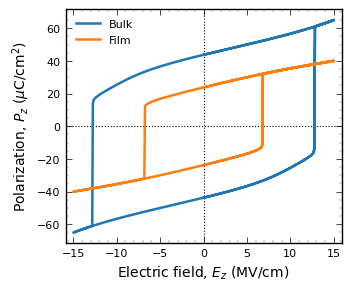

In [28]:
# Plot hysteresis loops
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.ticker import AutoMinorLocator

# =============================
# Inputs
# =============================
csv1 = Path("hysteresis_P_E_film_PFM.csv")
csv2 = Path("hysteresis_P_E_bulk_PFM.csv")

xcol = "Ez_V_per_m"
ycol = "P_C_per_m2"

# =============================
# Unit conversion
# V/m -> MV/cm : 1e-8
# C/m^2 -> μC/cm^2 : 100
# =============================
XSCALE = 1e-8
YSCALE = 100.0

# =============================
# Plot style
# =============================
mpl.rcParams.update({
    "font.family": "DejaVu Sans",   # Change if non-Latin labels are needed
    "font.size": 9,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2.5,
    "ytick.minor.size": 2.5,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "xtick.minor.width": 0.2,
    "ytick.minor.width": 0.2,
    "legend.frameon": False,
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# =============================
# Load
# =============================
df1 = pd.read_csv(csv1)
df2 = pd.read_csv(csv2)

df1 = df1[[xcol, ycol]].apply(pd.to_numeric, errors="coerce").dropna()
df2 = df2[[xcol, ycol]].apply(pd.to_numeric, errors="coerce").dropna()

def prep_hysteresis(df, downsample=1):
    if downsample > 1:
        df = df.iloc[::downsample].copy()
    x = df[xcol].to_numpy() * XSCALE   # MV/cm
    y = df[ycol].to_numpy() * YSCALE   # μC/cm^2
    return x, y

# Downsample if the plot is too dense
downsample1 = 1
downsample2 = 1

x1, y1 = prep_hysteresis(df1, downsample=downsample1)
x2, y2 = prep_hysteresis(df2, downsample=downsample2)

# =============================
# Plot
# Single-column figure size
# =============================
fig, ax = plt.subplots(figsize=(3.4, 2.8), constrained_layout=True)

# Use sparse markers for readability
markevery1 = max(len(x1) // 30, 1)
markevery2 = max(len(x2) // 30, 1)

ax.plot(
    x2, y2,
    lw=1.8,
    label="Bulk"
)

ax.plot(
    x1, y1,
    lw=1.8,
    label="Film"
)

# Use converted units directly in axis labels
ax.set_xlabel(r"Electric field, $E_z$ (MV/cm)")
ax.set_ylabel(r"Polarization, $P_z$ ($\mu$C/cm$^2$)")

# Final plot styling
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.tick_params(which="both", top=True, right=True)

# Add light zero lines if needed
ax.axhline(0, color="black", lw=0.8, ls=":", zorder=0)
ax.axvline(0, color="black", lw=0.8, ls=":", zorder=0)

# Legend
ax.legend(loc="best", handlelength=2.2)

# Spine styling
for spine in ax.spines.values():
    spine.set_linewidth(1.0)

# Layout
ax.margins(x=0.03, y=0.05)

# Save
fig.savefig("hysteresis_loop.png", dpi=600)

plt.show()


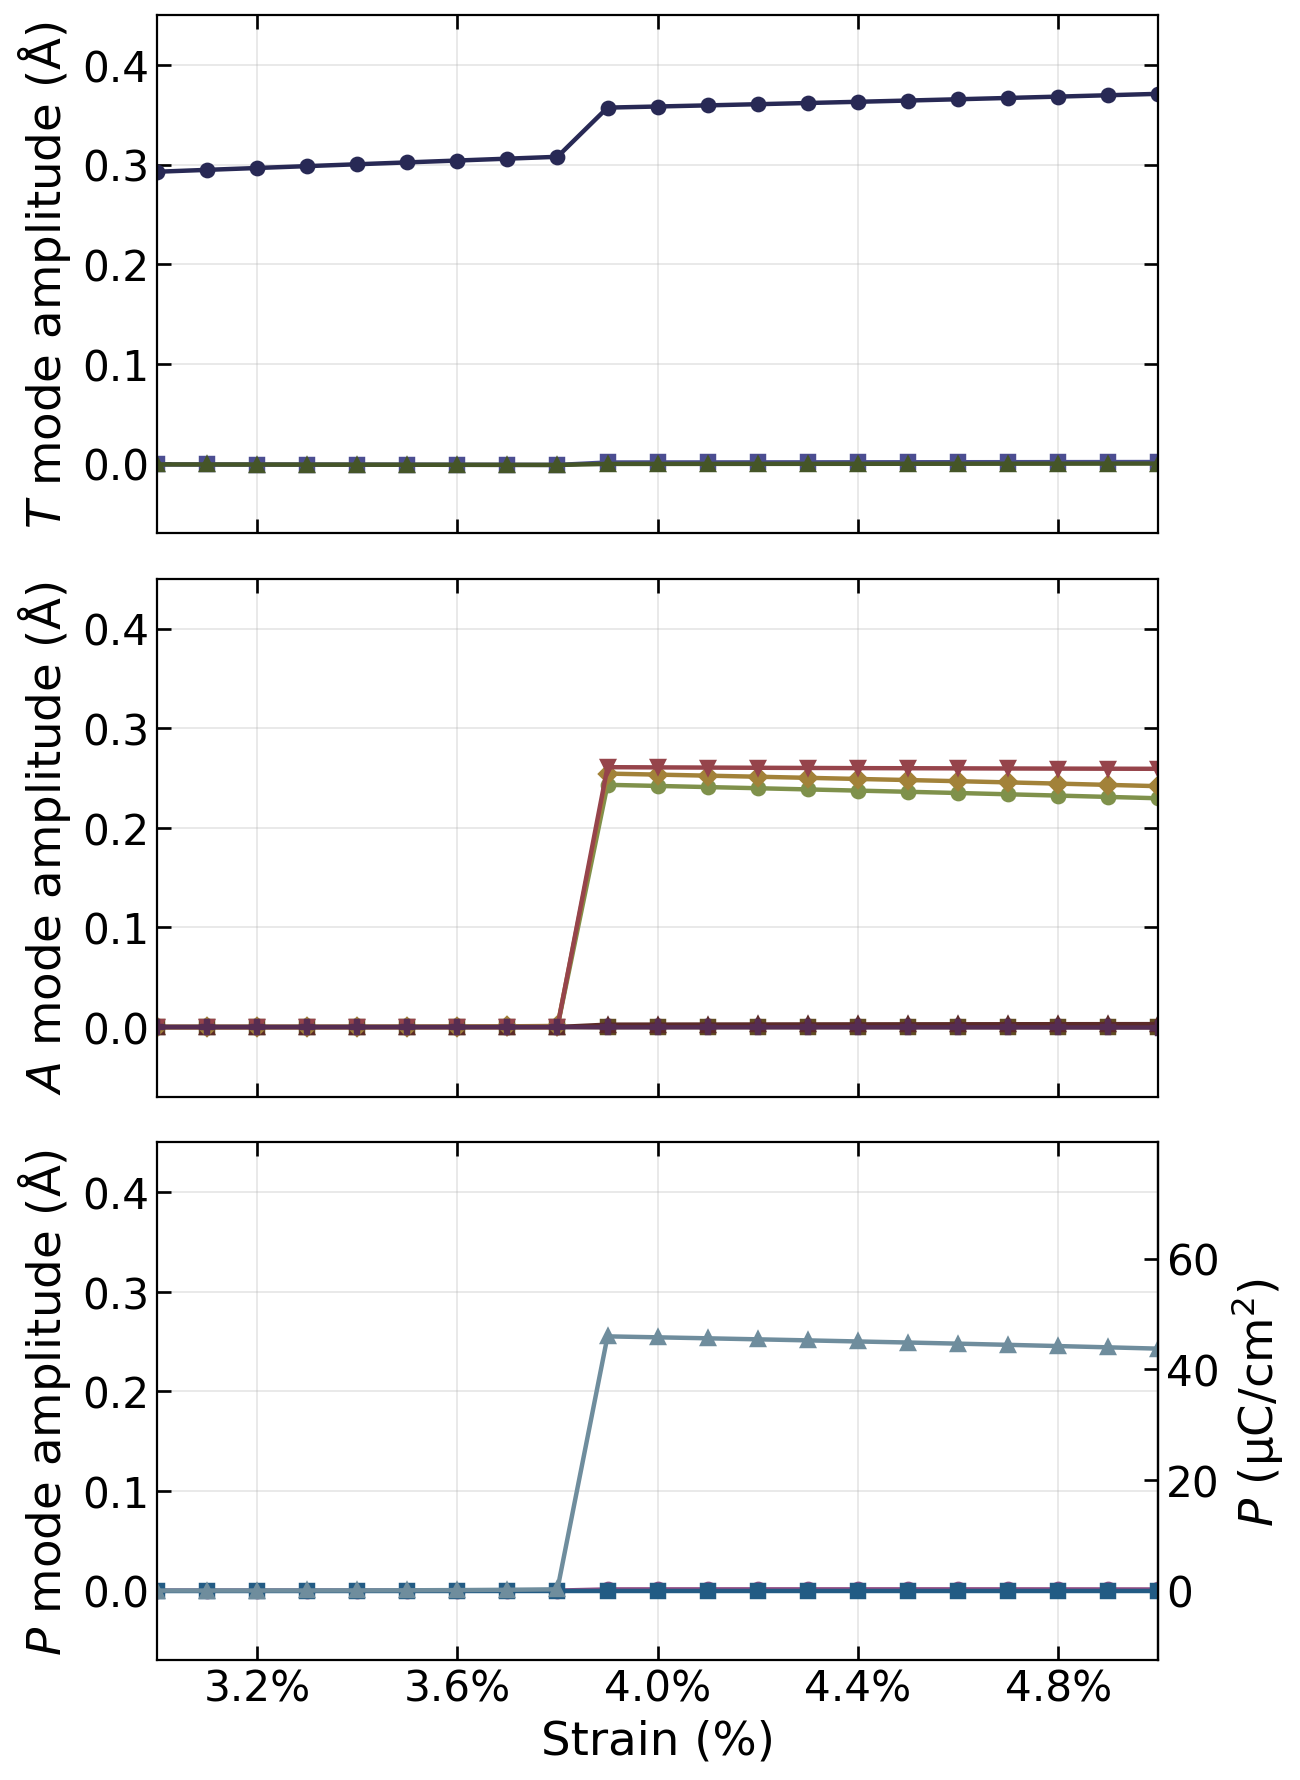

Saved figure: order_params_vs_strain_bulk.png


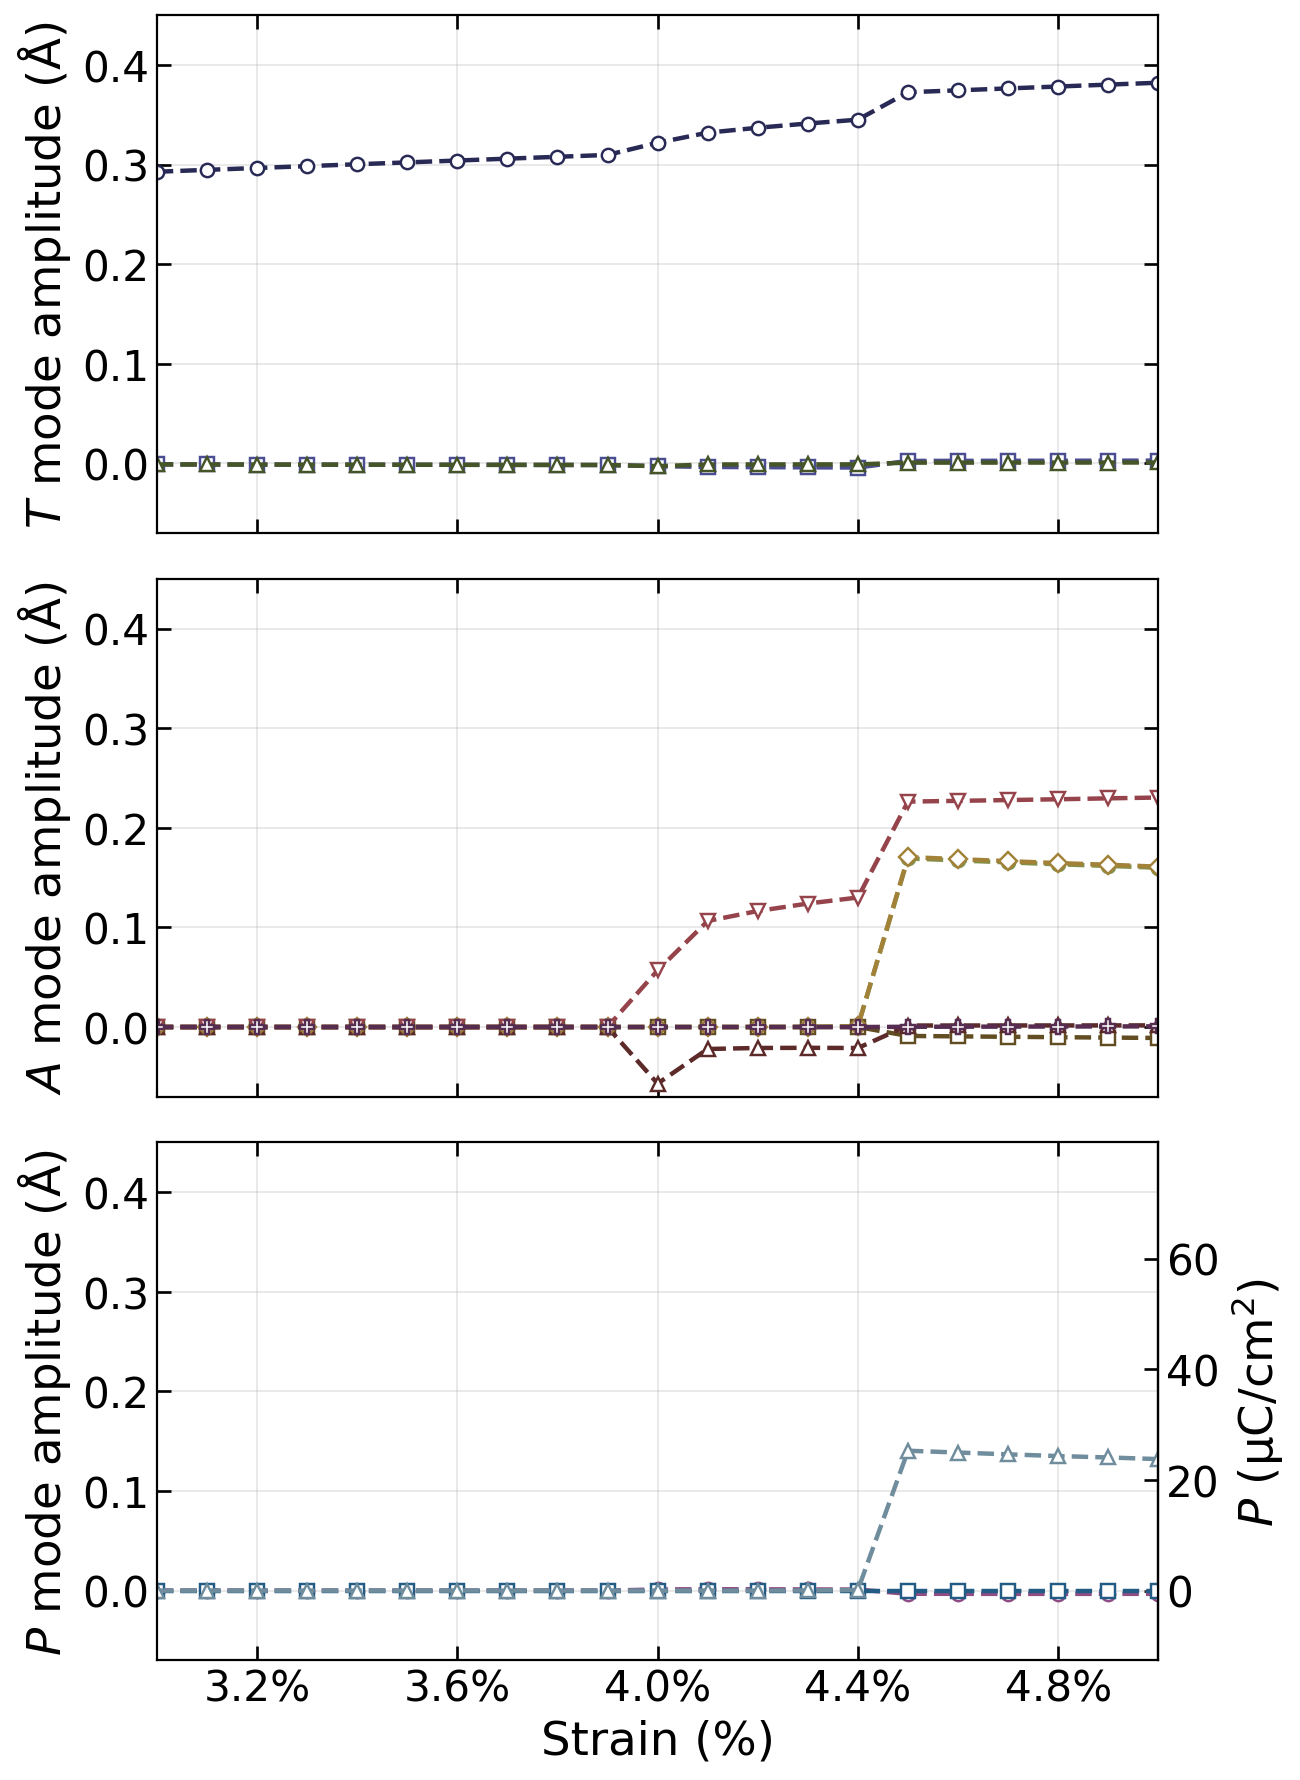

Saved figure: order_params_vs_strain_film.png


In [14]:
# Strain plot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter, MaxNLocator
from pathlib import Path
import matplotlib as mpl

def darken(cols, factor=0.75):
    cols = np.array(cols, dtype=float)
    cols[..., :3] *= factor
    cols[..., :3] = np.clip(cols[..., :3], 0, 1)
    return cols

# Input CSV
csv_film = Path("film_PFM_vs_strain_init1e-3_nonPy_500step_until1e-5_3-5%.csv")
csv_bulk = Path("bulk_PFM_vs_strain_init1e-3_nonPy_500step_until1e-5_3-5%.csv")

# Load and sort
df_film = pd.read_csv(csv_film).sort_values("strain").reset_index(drop=True) if csv_film.exists() else None
df_bulk = pd.read_csv(csv_bulk).sort_values("strain").reset_index(drop=True) if csv_bulk.exists() else None
if df_bulk is None:
    raise FileNotFoundError(f"Not found: {csv_bulk}")

# Normalize strain values
def normalize_strain(s):
    s = pd.to_numeric(s, errors="coerce").to_numpy()
    if np.nanmax(s) > 1.5:
        return s / 100.0
    return s

x_bulk = normalize_strain(df_bulk["strain"])
x_film = normalize_strain(df_film["strain"]) if df_film is not None else None

# Text style
mpl.rcParams.update({
    "figure.dpi": 160,
    "savefig.dpi": 300,
    "font.size": 19,
    "axes.labelsize": 21,
    "axes.titlesize": 19,
    "xtick.labelsize": 19,
    "ytick.labelsize": 19,
    "legend.fontsize": 17,
    "axes.linewidth": 1,
})

# Colors
c1 = mpl.colormaps["tab20b"](np.linspace(0, 1, 20))[::2]
c2 = mpl.colormaps["tab20c"](np.linspace(0, 1, 20))[::2]
colors = np.vstack([c1, c2])[:12]

# Smaller factor values make darker colors (for example: 0.8, 0.7, 0.6)
colors = darken(colors, factor=0.7)

mode_order = ["Tx","Ty","Tz","Axy","Axz","Ayz","Ayx","Azx","Azy","Px","Py","Pz"]
mode_color = {m: colors[i] for i, m in enumerate(mode_order)}

# Style definitions
def style_bulk(marker):
    return {"ls": "-", "marker": marker, "mfc": None}

def style_film(marker):
    return {"ls": "--", "marker": marker, "mfc": "white"}

# Plot helper
def linepts(ax, x, y, label, style, color):
    ax.plot(
        x, y,
        linestyle=style["ls"],
        linewidth=2.0,
        marker=style["marker"],
        markersize=6.0,
        markeredgewidth=1.1,
        markerfacecolor=style.get("mfc", "auto"),
        color=color,
        label=label
    )

def ang_to_c(y):   # 1 Å -> 180 μC/cm^2(adjust the coefficient if needed)
    return 180 * y

def c_to_ang(y):
    return y / 180

def make_plot(df, x, kind_label, out_png, line_style_fn, xlim=None, add_right_axis=True):
    plt.close("all")
    fig, axes = plt.subplots(3, 1, figsize=(8.5, 11.5), sharex=True)

    # ---- 1) T ----
    for name, mk in [("Tx", "o"), ("Ty", "s"), ("Tz", "^")]:
        if name in df.columns:
            linepts(
                axes[0], x,
                pd.to_numeric(df[name], errors="coerce").to_numpy(),
                f"{name} ({kind_label})", line_style_fn(mk),
                mode_color.get(name, "k")
            )
    axes[0].set_ylabel("$T$ mode amplitude (Å)")
    axes[0].grid(True, alpha=0.3)
    #axes[0].legend(ncol=2, frameon=False)

    # ---- 2) A modes: six series with separate colors ----
    A_list = [("Axy", "o"), ("Axz", "s"), ("Ayx", "^"), ("Ayz", "D"), ("Azx", "v"), ("Azy", "P")]
    for name, mk in A_list:
        if name in df.columns:
            linepts(
                axes[1], x,
                pd.to_numeric(df[name], errors="coerce").to_numpy(),
                f"{name} ({kind_label})", line_style_fn(mk),
                mode_color.get(name, "k")
            )
    axes[1].set_ylabel("$A$ mode amplitude (Å)")
    axes[1].grid(True, alpha=0.3)
    #axes[1].legend(ncol=2, frameon=False)

    # ---- 3) P ----
    for name, mk in [("Px", "o"), ("Py", "s"), ("Pz", "^")]:
        if name in df.columns:
            linepts(
                axes[2], x,
                pd.to_numeric(df[name], errors="coerce").to_numpy(),
                f"{name} ({kind_label})", line_style_fn(mk),
                mode_color.get(name, "k")
            )
    axes[2].set_xlabel("Strain (%)")
    axes[2].set_ylabel("$P$ mode amplitude (Å)")
    axes[2].grid(True, alpha=0.3)
    #axes[2].legend(ncol=2, frameon=False)

    # ---- x-axis as percent ----
    for i, ax in enumerate(axes):
        ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
        ax.tick_params(direction="in", top=True, right=(i != 2), length=6.5, width=1.2)
        ax.set_xmargin(0)
    axes[2].xaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=1))
    if xlim is not None:
        axes[2].set_xlim(*xlim)

    # ---- y-axis range, optionally fixed ----
    for ax in axes:
        ax.set_ylim(-0.07, 0.45)

    # ---- right axis for P only ----
    if add_right_axis:
        secax = axes[2].secondary_yaxis('right', functions=(ang_to_c, c_to_ang))
        secax.set_ylabel("$P$ (μC/cm$^2$)")
        secax.tick_params(direction="in", length=6.5, width=1.2, labelsize=19)
        secax.set_yticks(np.arange(0, 80, 20))

    plt.tight_layout()
    fig.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved figure: {out_png}")

# Use a shared x-axis range for film and bulk
xlim = (0.03, 0.05)

# Bulk
make_plot(
    df=df_bulk, x=x_bulk,
    kind_label="bulk",
    out_png="order_params_vs_strain_bulk.png",
    line_style_fn=style_bulk,
    xlim=xlim,
    add_right_axis=True
)

# Film, if available
if df_film is not None:
    make_plot(
        df=df_film, x=x_film,
        kind_label="film",
        out_png="order_params_vs_strain_film.png",
        line_style_fn=style_film,
        xlim=xlim,
        add_right_axis=True
    )


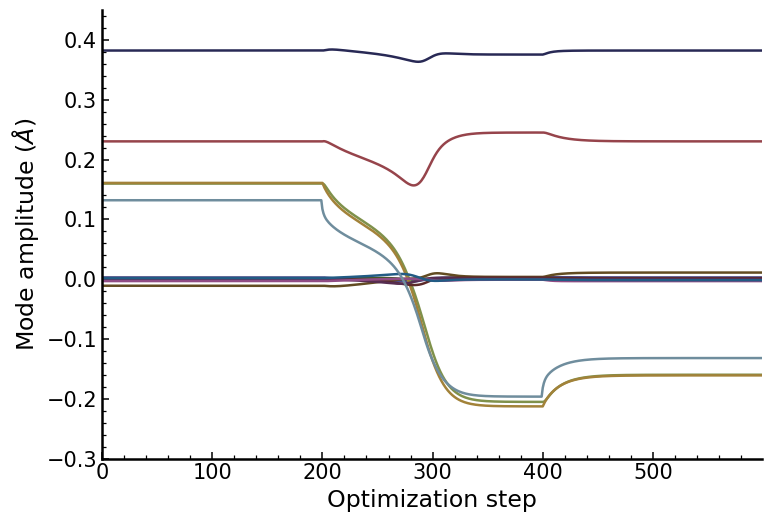

In [13]:
# Plot electric-field protocol
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# =========================
# Data
# =========================
df = pd.read_csv("center_mode_displacements_Ez_protocol.csv")

mode_names = [
    "Tx", "Ty", "Tz",
    "Axy", "Axz", "Ayz",
    "Ayx", "Azx", "Azy",
    "Px", "Py", "Pz"
]

# =========================
# Color
# =========================
def darken(colors, factor=0.7):
    colors = np.array(colors).copy()
    colors[:, :3] *= factor
    return np.clip(colors, 0, 1)

c1 = mpl.colormaps["tab20b"](np.linspace(0, 1, 20))[::2]
c2 = mpl.colormaps["tab20c"](np.linspace(0, 1, 20))[::2]
colors = np.vstack([c1, c2])[:12]
colors = darken(colors, factor=0.7)

# =========================
# Plot style
# =========================
mpl.rcParams["font.family"] = "DejaVu Sans"
mpl.rcParams["font.size"] = 16
mpl.rcParams["axes.labelsize"] = 17
mpl.rcParams["axes.linewidth"] = 1.2
mpl.rcParams["xtick.labelsize"] = 15
mpl.rcParams["ytick.labelsize"] = 15
mpl.rcParams["legend.fontsize"] = 11
mpl.rcParams["xtick.direction"] = "in"
mpl.rcParams["ytick.direction"] = "in"
mpl.rcParams["xtick.major.size"] = 8
mpl.rcParams["ytick.major.size"] = 8
mpl.rcParams["xtick.minor.size"] = 3
mpl.rcParams["ytick.minor.size"] = 3

# =========================
# plot
# =========================
fig, ax = plt.subplots(figsize=(8.0, 5.5))

for i, mode in enumerate(mode_names):
    ax.plot(
        df["step"],
        df[mode],
        label=mode,
        linewidth=1.8,
        color=colors[i]
    )

# Axis range
ax.set_xlim(df["step"].min(), df["step"].max())
ax.set_ylim(-0.3, 0.45)

# Labels
ax.set_xlabel("Optimization step")
ax.set_ylabel(r"Mode amplitude ($\AA$)")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.8)
ax.spines["bottom"].set_linewidth(1.8)

# Ticks
ax.minorticks_on()
ax.tick_params(which="both", direction="in")
ax.tick_params(which="major", length=5, width=1.1)
ax.tick_params(which="minor", length=3, width=0.9)

fig.tight_layout()
fig.savefig("modes_vs_timestep_Ez_film.png", dpi=600, bbox_inches="tight")
plt.show()
